# Textbook layout exploration

## Purpose

This notebook investigates the page layout and content boundaries of the Das and Sobhan textbook before implementing the production preprocessing pipeline.

The investigation will identify the exact page coordinates of the `Problems`, `References`, `Answers to Selected Problems` and `Index` headings. These boundaries will later be used to exclude problem statements, question parts and selected answers from the RAG knowledge corpus.

This notebook is exploratory only. It must not create embeddings, construct the FAISS index or pass the unfiltered PDF to any retrieval or generation component.

In [1]:
from hashlib import sha256
from pathlib import Path

import pymupdf


SOURCE_RELATIVE_PATH = Path(
    "data/raw/corpus/"
    "das-sobhan-principles-geotechnical-engineering-8e-si.pdf"
)
EXPECTED_SHA256 = (
    "734cc8ad0824bbe8ae5f21db5bd5f9dd"
    "1850a620c4f85f497daf55d64cd65be6"
)
EXPECTED_SIZE_BYTES = 34_607_091
EXPECTED_PAGE_COUNT = 770


def find_project_root(start: Path) -> Path:
    """Find the repository root independently of the notebook working directory."""
    for candidate in (start, *start.parents):
        if (
            (candidate / ".git").exists()
            and (candidate / "requirements.in").is_file()
        ):
            return candidate

    raise FileNotFoundError("Could not locate the thesis repository root.")


def calculate_sha256(path: Path) -> str:
    """Calculate a file checksum without loading the complete PDF into memory."""
    digest = sha256()

    with path.open("rb") as source_file:
        for block in iter(lambda: source_file.read(1024 * 1024), b""):
            digest.update(block)

    return digest.hexdigest()


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_PATH = PROJECT_ROOT / SOURCE_RELATIVE_PATH

assert SOURCE_PATH.is_file(), f"Textbook not found: {SOURCE_RELATIVE_PATH}"
assert SOURCE_PATH.stat().st_size == EXPECTED_SIZE_BYTES

actual_sha256 = calculate_sha256(SOURCE_PATH)
assert actual_sha256 == EXPECTED_SHA256

document = pymupdf.open(SOURCE_PATH)

assert document.is_pdf
assert document.page_count == EXPECTED_PAGE_COUNT

print(f"Source: {SOURCE_RELATIVE_PATH}")
print(f"Size verified: {SOURCE_PATH.stat().st_size} bytes")
print(f"SHA-256 verified: {actual_sha256}")
print(f"Pages verified: {document.page_count}")

Source: data/raw/corpus/das-sobhan-principles-geotechnical-engineering-8e-si.pdf
Size verified: 34607091 bytes
SHA-256 verified: 734cc8ad0824bbe8ae5f21db5bd5f9dd1850a620c4f85f497daf55d64cd65be6
Pages verified: 770


## Boundary-heading inventory

The first layout check searches for exact heading lines without retaining the surrounding textbook content. Each match records its one-based PDF page number and bounding box.

This distinguishes the PDF page number from the page number printed inside the textbook. Printed-page mapping will be investigated separately.

This approach groups positioned words into their original PDF lines and only retains a match when the complete normalised line equals one of our four headings. Therefore, a sentence merely containing the word “problems” or “references” will not be accepted as a boundary.

The purpose of this cell is to discover the actual pattern before we define what the program must require.

In [2]:
from collections import Counter, defaultdict


TARGET_HEADINGS = (
    "Problems",
    "References",
    "Answers to Selected Problems",
    "Index",
)


def collect_exact_heading_matches(
    pdf_document: pymupdf.Document,
    target_headings: tuple[str, ...],
) -> list[dict]:
    """Find exact heading lines and preserve their PDF coordinates."""
    matches = []
    target_set = set(target_headings)

    for page_index in range(pdf_document.page_count):
        page = pdf_document.load_page(page_index)
        lines = defaultdict(list)

        for word in page.get_text("words", sort=False):
            block_number = word[5]
            line_number = word[6]
            lines[(block_number, line_number)].append(word)

        for (block_number, line_number), line_words in lines.items():
            ordered_words = sorted(line_words, key=lambda item: item[7])
            line_text = " ".join(word[4] for word in ordered_words)
            normalised_text = " ".join(line_text.split())

            if normalised_text not in target_set:
                continue

            x0 = min(word[0] for word in ordered_words)
            y0 = min(word[1] for word in ordered_words)
            x1 = max(word[2] for word in ordered_words)
            y1 = max(word[3] for word in ordered_words)

            matches.append(
                {
                    "heading": normalised_text,
                    "pdf_page_index": page_index,
                    "pdf_page_number": page_index + 1,
                    "bbox": tuple(
                        round(coordinate, 2)
                        for coordinate in (x0, y0, x1, y1)
                    ),
                    "block_number": block_number,
                    "line_number": line_number,
                }
            )

    return sorted(
        matches,
        key=lambda match: (
            match["pdf_page_index"],
            match["bbox"][1],
            match["bbox"][0],
        ),
    )


heading_matches = collect_exact_heading_matches(
    document,
    TARGET_HEADINGS,
)
heading_counts = Counter(
    match["heading"] for match in heading_matches
)

print("Exact heading counts:")
for heading in TARGET_HEADINGS:
    print(f"  {heading}: {heading_counts.get(heading, 0)}")

print("\nHeading locations:")
for match in heading_matches:
    print(
        f"  PDF page {match['pdf_page_number']:>3} | "
        f"{match['heading']:<28} | "
        f"bbox={match['bbox']}"
    )

Exact heading counts:
  Problems: 56
  References: 48
  Answers to Selected Problems: 9
  Index: 6

Heading locations:
  PDF page  15 | References                   | bbox=(154.02, 465.71, 202.88, 476.71)
  PDF page  16 | Problems                     | bbox=(136.0, 116.31, 177.56, 127.31)
  PDF page  16 | References                   | bbox=(136.0, 130.31, 184.86, 141.31)
  PDF page  16 | Problems                     | bbox=(136.0, 368.8, 177.56, 379.8)
  PDF page  16 | References                   | bbox=(136.0, 382.8, 184.86, 393.8)
  PDF page  16 | Problems                     | bbox=(135.99, 579.32, 177.55, 590.32)
  PDF page  16 | References                   | bbox=(135.99, 593.32, 184.85, 604.32)
  PDF page  17 | Problems                     | bbox=(154.0, 169.51, 195.56, 180.51)
  PDF page  17 | References                   | bbox=(154.0, 183.51, 202.86, 194.51)
  PDF page  17 | Problems                     | bbox=(154.0, 458.53, 195.56, 469.53)
  PDF page  17 | References     

The output is useful because it proves that **exact text matching alone is not safe**. It found three different uses of the same words:

| Candidate type        | Evidence                                          |
| --------------------- | ------------------------------------------------- |
| Contents entries      | PDF pages 15–23                                   |
| Running page headers  | Usually `y0 ≈ 24`, such as `Problems` on page 115 |
| Real section headings | Inside the page body, usually `y0 ≥ 50`           |

After separating them, the result becomes:

| Heading                      | Contents | Running header | Body candidate |
| ---------------------------- | -------: | -------------: | -------------: |
| Problems                     |       15 |             25 |             16 |
| References                   |       17 |             13 |             18 |
| Answers to Selected Problems |        1 |              7 |              1 |
| Index                        |        1 |              4 |              1 |

The 16 body `Problems` headings are the real chapter problem sections. There are 18 body `References` headings because:

* PDF page 37 contains the References for Chapter 1, which has no problem section to exclude;
* PDF page 737 contains the References for Appendix A;
* the other 16 References headings close the 16 problem sections.

The real answer section starts on PDF page 738, and the real Index starts on PDF page 746. This means the selected-answer exclusion is exactly PDF pages 738–745.

## Preliminary candidate classification

The exact-line search also detects table-of-contents entries and repeating page headers. These are not section boundaries.

For this verified textbook file:

- matches on PDF pages 15-23 belong to the contents;
- matches with a top coordinate below 40 points belong to the running-header area;
- the remaining matches are body candidates.

A `Problems` body candidate is paired with the next unused `References` body candidate. References that occur without a preceding problem section remain part of the retained textbook content.

In [3]:
CONTENTS_MATCH_FIRST_PAGE = 15
CONTENTS_MATCH_LAST_PAGE = 23
RUNNING_HEADER_Y_LIMIT = 40.0

CANDIDATE_TYPES = (
    "contents",
    "running_header",
    "body",
)


def classify_heading_match(match: dict) -> str:
    """Classify an exact heading match by its observed page region."""
    pdf_page_number = match["pdf_page_number"]
    y0 = match["bbox"][1]

    if (
        CONTENTS_MATCH_FIRST_PAGE
        <= pdf_page_number
        <= CONTENTS_MATCH_LAST_PAGE
    ):
        return "contents"

    if y0 < RUNNING_HEADER_Y_LIMIT:
        return "running_header"

    return "body"


classified_heading_matches = [
    {
        **match,
        "candidate_type": classify_heading_match(match),
    }
    for match in heading_matches
]

classified_counts = Counter(
    (
        match["heading"],
        match["candidate_type"],
    )
    for match in classified_heading_matches
)

print("Classified heading counts:")
for heading in TARGET_HEADINGS:
    print(f"\n{heading}")
    for candidate_type in CANDIDATE_TYPES:
        count = classified_counts.get(
            (heading, candidate_type),
            0,
        )
        print(f"  {candidate_type:<14}: {count}")

Classified heading counts:

Problems
  contents      : 15
  running_header: 25
  body          : 16

References
  contents      : 17
  running_header: 13
  body          : 18

Answers to Selected Problems
  contents      : 1
  running_header: 7
  body          : 1

Index
  contents      : 1
  running_header: 4
  body          : 1


In [4]:
def document_position(match: dict) -> tuple:
    """Return a sortable position inside the complete PDF."""
    return (
        match["pdf_page_index"],
        match["bbox"][1],
        match["bbox"][0],
    )


body_matches = [
    match
    for match in classified_heading_matches
    if match["candidate_type"] == "body"
]

problem_starts = sorted(
    (
        match
        for match in body_matches
        if match["heading"] == "Problems"
    ),
    key=document_position,
)

available_references = sorted(
    (
        match
        for match in body_matches
        if match["heading"] == "References"
    ),
    key=document_position,
)

problem_reference_pairs = []

for problem_start in problem_starts:
    later_references = [
        reference
        for reference in available_references
        if document_position(reference)
        > document_position(problem_start)
    ]

    if not later_references:
        raise RuntimeError(
            "No later References heading was found for "
            f"Problems on PDF page "
            f"{problem_start['pdf_page_number']}."
        )

    reference_start = later_references[0]

    problem_reference_pairs.append(
        {
            "problem_start": problem_start,
            "reference_start": reference_start,
        }
    )
    available_references.remove(reference_start)

print(f"Problem–References pairs: {len(problem_reference_pairs)}")

for pair_number, pair in enumerate(
    problem_reference_pairs,
    start=1,
):
    problem_start = pair["problem_start"]
    reference_start = pair["reference_start"]

    print(
        f"  Pair {pair_number:>2}: "
        f"Problems PDF page "
        f"{problem_start['pdf_page_number']:>3} "
        f"at y={problem_start['bbox'][1]:>6.2f} "
        f"-> References PDF page "
        f"{reference_start['pdf_page_number']:>3} "
        f"at y={reference_start['bbox'][1]:>6.2f}"
    )

print(
    "\nUnpaired body References pages:",
    [
        match["pdf_page_number"]
        for match in available_references
    ],
)

answer_body_matches = [
    match
    for match in body_matches
    if match["heading"] == "Answers to Selected Problems"
]

index_body_matches = [
    match
    for match in body_matches
    if match["heading"] == "Index"
]

print(
    "Answer-section body pages:",
    [
        match["pdf_page_number"]
        for match in answer_body_matches
    ],
)
print(
    "Index body pages:",
    [
        match["pdf_page_number"]
        for match in index_body_matches
    ],
)

Problem–References pairs: 16
  Pair  1: Problems PDF page  87 at y= 50.41 -> References PDF page  90 at y=400.41
  Pair  2: Problems PDF page 114 at y=413.31 -> References PDF page 116 at y=551.78
  Pair  3: Problems PDF page 144 at y= 50.41 -> References PDF page 145 at y=452.96
  Pair  4: Problems PDF page 166 at y=420.41 -> References PDF page 169 at y=485.53
  Pair  5: Problems PDF page 216 at y=488.38 -> References PDF page 219 at y=496.97
  Pair  6: Problems PDF page 261 at y=138.04 -> References PDF page 265 at y=354.05
  Pair  7: Problems PDF page 291 at y=452.68 -> References PDF page 294 at y=225.72
  Pair  8: Problems PDF page 324 at y=178.64 -> References PDF page 328 at y=438.37
  Pair  9: Problems PDF page 370 at y= 50.41 -> References PDF page 376 at y= 50.41
  Pair 10: Problems PDF page 445 at y= 50.41 -> References PDF page 451 at y= 50.41
  Pair 11: Problems PDF page 509 at y= 50.41 -> References PDF page 513 at y=342.71
  Pair 12: Problems PDF page 569 at y=267.41 ->

The classification and pairing worked correctly.

The 16 pairs are ordered, non-overlapping and correspond to Chapters 2–17. The two unpaired References are valid retained content:

* PDF page 37: Chapter 1 References;
* PDF page 737: Appendix A References.

The selected answers start on PDF page 738, immediately after Appendix A, and the Index starts on PDF page 746. Therefore, none of these extra References will be accidentally treated as part of a problem section.

## Validated boundary pattern

The source-specific candidate classification produced 16 ordered `Problems`–`References` pairs corresponding to Chapters 2–17.

The body-level `References` headings on PDF pages 37 and 737 remain unpaired because they belong to Chapter 1 and Appendix A respectively. They are retained rather than treated as exclusion boundaries.

The selected-answer section begins on PDF page 738. The Index begins on PDF page 746 and marks the end of the answer section.

The following validation converts these observed properties into fail-fast requirements for this verified textbook file.

In [5]:
EXPECTED_CLASSIFIED_COUNTS = Counter(
    {
        ("Problems", "contents"): 15,
        ("Problems", "running_header"): 25,
        ("Problems", "body"): 16,
        ("References", "contents"): 17,
        ("References", "running_header"): 13,
        ("References", "body"): 18,
        ("Answers to Selected Problems", "contents"): 1,
        ("Answers to Selected Problems", "running_header"): 7,
        ("Answers to Selected Problems", "body"): 1,
        ("Index", "contents"): 1,
        ("Index", "running_header"): 4,
        ("Index", "body"): 1,
    }
)

EXPECTED_PROBLEM_PAGES = (
    87,
    114,
    144,
    166,
    216,
    261,
    291,
    324,
    370,
    445,
    509,
    569,
    598,
    662,
    697,
    727,
)

EXPECTED_REFERENCE_PAGES = (
    90,
    116,
    145,
    169,
    219,
    265,
    294,
    328,
    376,
    451,
    513,
    573,
    600,
    666,
    700,
    728,
)

EXPECTED_UNPAIRED_REFERENCE_PAGES = (
    37,
    737,
)

EXPECTED_ANSWER_START_PAGE = 738
EXPECTED_INDEX_START_PAGE = 746


assert classified_counts == EXPECTED_CLASSIFIED_COUNTS

actual_problem_pages = tuple(
    pair["problem_start"]["pdf_page_number"]
    for pair in problem_reference_pairs
)
actual_reference_pages = tuple(
    pair["reference_start"]["pdf_page_number"]
    for pair in problem_reference_pairs
)

assert actual_problem_pages == EXPECTED_PROBLEM_PAGES
assert actual_reference_pages == EXPECTED_REFERENCE_PAGES

paired_reference_positions = {
    document_position(pair["reference_start"])
    for pair in problem_reference_pairs
}

all_body_references = sorted(
    (
        match
        for match in body_matches
        if match["heading"] == "References"
    ),
    key=document_position,
)

actual_unpaired_reference_pages = tuple(
    reference["pdf_page_number"]
    for reference in all_body_references
    if document_position(reference)
    not in paired_reference_positions
)

assert (
    actual_unpaired_reference_pages
    == EXPECTED_UNPAIRED_REFERENCE_PAGES
)

assert len(answer_body_matches) == 1
assert (
    answer_body_matches[0]["pdf_page_number"]
    == EXPECTED_ANSWER_START_PAGE
)

assert len(index_body_matches) == 1
assert (
    index_body_matches[0]["pdf_page_number"]
    == EXPECTED_INDEX_START_PAGE
)

for pair_index, pair in enumerate(problem_reference_pairs):
    problem_position = document_position(
        pair["problem_start"]
    )
    reference_position = document_position(
        pair["reference_start"]
    )

    assert problem_position < reference_position

    if pair_index + 1 < len(problem_reference_pairs):
        next_problem_position = document_position(
            problem_reference_pairs[
                pair_index + 1
            ]["problem_start"]
        )
        assert reference_position < next_problem_position

assert (
    document_position(problem_reference_pairs[-1]["reference_start"])
    < document_position(answer_body_matches[0])
    < document_position(index_body_matches[0])
)

print("Boundary inventory validation: PASSED")
print(
    "Validated problem sections:",
    len(problem_reference_pairs),
)
print(
    "Unpaired retained References pages:",
    list(actual_unpaired_reference_pages),
)
print(
    "Selected-answer start page:",
    answer_body_matches[0]["pdf_page_number"],
)
print(
    "Index start page:",
    index_body_matches[0]["pdf_page_number"],
)

Boundary inventory validation: PASSED
Validated problem sections: 16
Unpaired retained References pages: [37, 737]
Selected-answer start page: 738
Index start page: 746


After validation passes, we’ll construct page-coordinate exclusion regions and calculate exactly which parts of each mixed page are retained.

The validation passed exactly. We now have reliable boundaries rather than assumptions.

This next step uses half-open intervals: `[start, end)`.

* The `Problems` heading is included in the exclusion.
* The paired `References` heading is retained.
* The selected-answer heading is excluded.
* The `Index` heading is retained temporarily because it is only the answer section’s closing boundary. We can assess the Index separately when defining the final corpus scope.

This coordinate-aware method is stronger for the dissertation methodology because deleting whole pages would also delete valid textbook explanations and references.

## Coordinate-based exclusion intervals

Each excluded section is represented as a half-open document interval: `[start, end)`.

For a chapter problem section, the interval begins at the top coordinate of the `Problems` heading and ends immediately before the paired `References` heading. This removes the problem heading and problem material while retaining the chapter references.

The selected-answer interval begins at `Answers to Selected Problems` and ends immediately before `Index`.

Using document coordinates avoids deleting valid explanatory or reference content that shares a PDF page with excluded material.

In [6]:
def make_exclusion_interval(
    section_id: str,
    content_type: str,
    start_match: dict,
    end_match: dict,
) -> dict:
    """Create one validated half-open exclusion interval."""

    # Extract the start and end positions from the detected headings.
    start_page_index = start_match["pdf_page_index"]
    end_page_index = end_match["pdf_page_index"]
    start_y = float(start_match["bbox"][1])
    end_y = float(end_match["bbox"][1])

    # Ensure that the exclusion begins before it ends.
    if (start_page_index, start_y) >= (
        end_page_index,
        end_y,
    ):
        raise ValueError(
            f"Invalid exclusion interval: {section_id}"
        )

    # Store both zero-based indices and one-based PDF page numbers.
    return {
        "section_id": section_id,
        "content_type": content_type,
        "start_page_index": start_page_index,
        "start_pdf_page_number": start_page_index + 1,
        "start_y": start_y,
        "end_page_index": end_page_index,
        "end_pdf_page_number": end_page_index + 1,
        "end_y": end_y,
    }


# Convert the 16 validated problem-reference pairs into intervals.
problem_exclusions = [
    make_exclusion_interval(
        section_id=f"problems_{pair_number:02d}",
        content_type="problems",
        start_match=pair["problem_start"],
        end_match=pair["reference_start"],
    )
    for pair_number, pair in enumerate(
        problem_reference_pairs,
        start=1,
    )
]

# Build the separate interval containing the selected answers.
answer_exclusion = make_exclusion_interval(
    section_id="selected_answers",
    content_type="selected_answers",
    start_match=answer_body_matches[0],
    end_match=index_body_matches[0],
)

# Combine both content types into one ordered exclusion inventory.
exclusion_intervals = [
    *problem_exclusions,
    answer_exclusion,
]

print(
    "Coordinate exclusion intervals:",
    len(exclusion_intervals),
)

# Display every boundary for manual verification.
for interval in exclusion_intervals:
    print(
        f"  {interval['section_id']:<17} | "
        f"PDF page "
        f"{interval['start_pdf_page_number']:>3} "
        f"y={interval['start_y']:>6.2f} "
        f"-> PDF page "
        f"{interval['end_pdf_page_number']:>3} "
        f"y={interval['end_y']:>6.2f}"
    )

Coordinate exclusion intervals: 17
  problems_01       | PDF page  87 y= 50.41 -> PDF page  90 y=400.41
  problems_02       | PDF page 114 y=413.31 -> PDF page 116 y=551.78
  problems_03       | PDF page 144 y= 50.41 -> PDF page 145 y=452.96
  problems_04       | PDF page 166 y=420.41 -> PDF page 169 y=485.53
  problems_05       | PDF page 216 y=488.38 -> PDF page 219 y=496.97
  problems_06       | PDF page 261 y=138.04 -> PDF page 265 y=354.05
  problems_07       | PDF page 291 y=452.68 -> PDF page 294 y=225.72
  problems_08       | PDF page 324 y=178.64 -> PDF page 328 y=438.37
  problems_09       | PDF page 370 y= 50.41 -> PDF page 376 y= 50.41
  problems_10       | PDF page 445 y= 50.41 -> PDF page 451 y= 50.41
  problems_11       | PDF page 509 y= 50.41 -> PDF page 513 y=342.71
  problems_12       | PDF page 569 y=267.41 -> PDF page 573 y= 50.35
  problems_13       | PDF page 598 y=311.64 -> PDF page 600 y=298.14
  problems_14       | PDF page 662 y=355.58 -> PDF page 666 y=453.59

In [7]:
# Calculate retained page regions

from collections import Counter, defaultdict


COORDINATE_TOLERANCE = 1e-6


def merge_vertical_intervals(
    intervals: list[tuple[float, float]],
    tolerance: float = COORDINATE_TOLERANCE,
) -> list[tuple[float, float]]:
    """Merge overlapping or touching vertical intervals."""

    # Return immediately when the page has no exclusions.
    if not intervals:
        return []

    # Sort intervals by their upper coordinate.
    ordered_intervals = sorted(intervals)
    merged_intervals = [ordered_intervals[0]]

    # Extend the previous interval when two ranges overlap or touch.
    for y0, y1 in ordered_intervals[1:]:
        previous_y0, previous_y1 = merged_intervals[-1]

        if y0 <= previous_y1 + tolerance:
            merged_intervals[-1] = (
                previous_y0,
                max(previous_y1, y1),
            )
        else:
            merged_intervals.append((y0, y1))

    return merged_intervals


def complement_vertical_intervals(
    excluded_intervals: list[tuple[float, float]],
    page_height: float,
    tolerance: float = COORDINATE_TOLERANCE,
) -> list[tuple[float, float]]:
    """Calculate the retained complement of the exclusions."""

    retained_intervals = []
    cursor_y = 0.0

    # Retain every gap occurring before an excluded interval.
    for excluded_y0, excluded_y1 in excluded_intervals:
        if excluded_y0 > cursor_y + tolerance:
            retained_intervals.append(
                (cursor_y, excluded_y0)
            )

        cursor_y = max(cursor_y, excluded_y1)

    # Retain the final gap between the last exclusion and page bottom.
    if cursor_y < page_height - tolerance:
        retained_intervals.append(
            (cursor_y, page_height)
        )

    return retained_intervals


def build_page_geometry(
    pdf_document: pymupdf.Document,
    section_intervals: list[dict],
) -> list[dict]:
    """Convert document intervals into page-level geometry."""

    # Collect the raw vertical exclusions assigned to each page.
    raw_page_exclusions = defaultdict(list)

    for section in section_intervals:
        # Visit every page touched by the document interval.
        for page_index in range(
            section["start_page_index"],
            section["end_page_index"] + 1,
        ):
            page = pdf_document.load_page(page_index)
            page_height = float(page.rect.height)

            # On the first page, exclusion begins at the heading.
            if page_index == section["start_page_index"]:
                excluded_y0 = section["start_y"]
            else:
                excluded_y0 = 0.0

            # On the final page, exclusion ends at the next heading.
            if page_index == section["end_page_index"]:
                excluded_y1 = section["end_y"]
            else:
                excluded_y1 = page_height

            # Reject any interval outside the physical page.
            if not (
                0.0
                <= excluded_y0
                < excluded_y1
                <= page_height
            ):
                raise ValueError(
                    "Invalid page exclusion for "
                    f"{section['section_id']} on PDF page "
                    f"{page_index + 1}: "
                    f"({excluded_y0}, {excluded_y1})"
                )

            raw_page_exclusions[page_index].append(
                (excluded_y0, excluded_y1)
            )

    page_inventory = []

    # Calculate excluded and retained regions for every PDF page.
    for page_index in range(pdf_document.page_count):
        page = pdf_document.load_page(page_index)
        page_width = float(page.rect.width)
        page_height = float(page.rect.height)

        excluded_intervals = merge_vertical_intervals(
            raw_page_exclusions.get(page_index, [])
        )
        retained_intervals = complement_vertical_intervals(
            excluded_intervals,
            page_height,
        )

        # Classify the page according to its remaining geometry.
        if not excluded_intervals:
            page_state = "fully_retained"
        elif (
            len(excluded_intervals) == 1
            and excluded_intervals[0][0] == 0.0
            and excluded_intervals[0][1] == page_height
        ):
            page_state = "fully_excluded"
        else:
            page_state = "partially_retained"

        page_inventory.append(
            {
                "pdf_page_index": page_index,
                "pdf_page_number": page_index + 1,
                "page_width": page_width,
                "page_height": page_height,
                "state": page_state,
                "excluded_y_intervals": excluded_intervals,
                "retained_y_intervals": retained_intervals,
            }
        )

    return page_inventory


# Build the page-level inventory without modifying the source PDF.
page_geometry = build_page_geometry(
    document,
    exclusion_intervals,
)

# Count pages belonging to each geometric state.
page_state_counts = Counter(
    page["state"] for page in page_geometry
)

print("Page geometry summary:")

for page_state in (
    "fully_retained",
    "fully_excluded",
    "partially_retained",
):
    print(
        f"  {page_state:<20}: "
        f"{page_state_counts.get(page_state, 0)}"
    )

print("\nMixed pages and retained y-ranges:")

# Show exactly what remains on every partially retained page.
for page in page_geometry:
    if page["state"] != "partially_retained":
        continue

    retained_description = ", ".join(
        f"[{y0:.2f}, {y1:.2f})"
        for y0, y1 in page["retained_y_intervals"]
    )

    print(
        f"  PDF page {page['pdf_page_number']:>3}: "
        f"{retained_description}"
    )

# Calculate the physical page area removed by the exclusions.
total_area = sum(
    page["page_width"] * page["page_height"]
    for page in page_geometry
)
excluded_area = sum(
    page["page_width"]
    * sum(
        y1 - y0
        for y0, y1 in page["excluded_y_intervals"]
    )
    for page in page_geometry
)
retained_area = total_area - excluded_area

# Confirm that this verified PDF uses one consistent page size.
unique_page_areas = {
    page["page_width"] * page["page_height"]
    for page in page_geometry
}

if len(unique_page_areas) != 1:
    raise ValueError(
        "Equivalent-page calculation requires one page size."
    )

standard_page_area = unique_page_areas.pop()

print("\nCoordinate-area check:")
print(f"  Excluded area: {excluded_area:.2f} square points")
print(f"  Retained area: {retained_area:.2f} square points")
print(
    f"  Excluded share: "
    f"{100 * excluded_area / total_area:.4f}%"
)
print(
    f"  Equivalent full pages: "
    f"{excluded_area / standard_page_area:.4f}"
)

Page geometry summary:
  fully_retained      : 692
  fully_excluded      : 44
  partially_retained  : 34

Mixed pages and retained y-ranges:
  PDF page  87: [0.00, 50.41)
  PDF page  90: [400.41, 658.00)
  PDF page 114: [0.00, 413.31)
  PDF page 116: [551.78, 658.00)
  PDF page 144: [0.00, 50.41)
  PDF page 145: [452.96, 658.00)
  PDF page 166: [0.00, 420.41)
  PDF page 169: [485.53, 658.00)
  PDF page 216: [0.00, 488.38)
  PDF page 219: [496.97, 658.00)
  PDF page 261: [0.00, 138.04)
  PDF page 265: [354.05, 658.00)
  PDF page 291: [0.00, 452.68)
  PDF page 294: [225.72, 658.00)
  PDF page 324: [0.00, 178.64)
  PDF page 328: [438.37, 658.00)
  PDF page 370: [0.00, 50.41)
  PDF page 376: [50.41, 658.00)
  PDF page 445: [0.00, 50.41)
  PDF page 451: [50.41, 658.00)
  PDF page 509: [0.00, 50.41)
  PDF page 513: [342.71, 658.00)
  PDF page 569: [0.00, 267.41)
  PDF page 573: [50.35, 658.00)
  PDF page 598: [0.00, 311.64)
  PDF page 600: [298.14, 658.00)
  PDF page 662: [0.00, 355.58)
  PD

The geometry results passed exactly:

* all 17 intended intervals were created;
* the 770 pages are fully accounted for;
* 44 pages are completely excluded;
* 34 pages contain a boundary and are partially retained;
* the remaining 692 pages are unaffected by these two exclusion rules;
* approximately 8.2636% of the total page area is excluded.

Now we should lock these results with assertions and inspect actual text around representative boundaries.

## Page-geometry validation and visual inspection

The page-level geometry is validated before any text extraction is attempted.

The numerical validation checks that:

- all 770 PDF pages receive exactly one page state;
- the fully excluded and partially retained pages match the validated section boundaries;
- retained and excluded vertical regions account for the complete height of every page;
- every section start and end coordinate appears in the corresponding retained-page geometry;
- the total excluded area matches the source-specific expected result.

Representative boundaries are then rendered with overlays because numerical agreement alone cannot demonstrate that a boundary does not cut through valid textbook content.

In [8]:
from math import isclose


EXPECTED_PAGE_STATE_COUNTS = Counter(
    {
        "fully_retained": 692,
        "fully_excluded": 44,
        "partially_retained": 34,
    }
)

EXPECTED_EXCLUDED_AREA = 22_273_898.36
EXPECTED_EXCLUDED_SHARE = 8.2636
EXPECTED_EQUIVALENT_FULL_PAGES = 63.6295


# The start and end page of every exclusion should be mixed pages.
expected_partially_retained_pages = tuple(
    sorted(
        (
            *EXPECTED_PROBLEM_PAGES,
            *EXPECTED_REFERENCE_PAGES,
            EXPECTED_ANSWER_START_PAGE,
            EXPECTED_INDEX_START_PAGE,
        )
    )
)

# Pages strictly between each pair should be fully excluded.
expected_fully_excluded_pages = tuple(
    page_number
    for problem_page, reference_page in zip(
        EXPECTED_PROBLEM_PAGES,
        EXPECTED_REFERENCE_PAGES,
    )
    for page_number in range(
        problem_page + 1,
        reference_page,
    )
) + tuple(
    range(
        EXPECTED_ANSWER_START_PAGE + 1,
        EXPECTED_INDEX_START_PAGE,
    )
)

# Retrieve the actual page numbers belonging to each state.
actual_partially_retained_pages = tuple(
    page["pdf_page_number"]
    for page in page_geometry
    if page["state"] == "partially_retained"
)

actual_fully_excluded_pages = tuple(
    page["pdf_page_number"]
    for page in page_geometry
    if page["state"] == "fully_excluded"
)

# Validate the overall page partition.
assert len(page_geometry) == EXPECTED_PAGE_COUNT
assert page_state_counts == EXPECTED_PAGE_STATE_COUNTS
assert sum(page_state_counts.values()) == EXPECTED_PAGE_COUNT

# Validate the exact pages assigned to both exclusion states.
assert (
    actual_partially_retained_pages
    == expected_partially_retained_pages
)
assert (
    actual_fully_excluded_pages
    == expected_fully_excluded_pages
)

# Build a lookup for validating individual page boundaries.
page_geometry_by_index = {
    page["pdf_page_index"]: page
    for page in page_geometry
}

# Confirm that retained and excluded areas cover each page exactly.
for page in page_geometry:
    excluded_height = sum(
        y1 - y0
        for y0, y1 in page["excluded_y_intervals"]
    )
    retained_height = sum(
        y1 - y0
        for y0, y1 in page["retained_y_intervals"]
    )

    assert isclose(
        excluded_height + retained_height,
        page["page_height"],
        rel_tol=0.0,
        abs_tol=COORDINATE_TOLERANCE,
    )

    # Fully excluded pages must contain no retained region.
    if page["state"] == "fully_excluded":
        assert page["retained_y_intervals"] == []

    # Fully retained pages must contain no excluded region.
    if page["state"] == "fully_retained":
        assert page["excluded_y_intervals"] == []
        assert page["retained_y_intervals"] == [
            (0.0, page["page_height"])
        ]

# Confirm that every section boundary is represented exactly.
for interval in exclusion_intervals:
    start_page = page_geometry_by_index[
        interval["start_page_index"]
    ]
    end_page = page_geometry_by_index[
        interval["end_page_index"]
    ]

    # The retained upper region must end where exclusion begins.
    assert any(
        isclose(
            retained_y1,
            interval["start_y"],
            rel_tol=0.0,
            abs_tol=COORDINATE_TOLERANCE,
        )
        for _, retained_y1
        in start_page["retained_y_intervals"]
    )

    # The retained lower region must begin where exclusion ends.
    assert any(
        isclose(
            retained_y0,
            interval["end_y"],
            rel_tol=0.0,
            abs_tol=COORDINATE_TOLERANCE,
        )
        for retained_y0, _
        in end_page["retained_y_intervals"]
    )

# Validate the source-specific area calculations.
actual_excluded_share = (
    100 * excluded_area / total_area
)
actual_equivalent_full_pages = (
    excluded_area / standard_page_area
)

assert isclose(
    excluded_area,
    EXPECTED_EXCLUDED_AREA,
    rel_tol=0.0,
    abs_tol=0.01,
)
assert isclose(
    actual_excluded_share,
    EXPECTED_EXCLUDED_SHARE,
    rel_tol=0.0,
    abs_tol=0.0001,
)
assert isclose(
    actual_equivalent_full_pages,
    EXPECTED_EQUIVALENT_FULL_PAGES,
    rel_tol=0.0,
    abs_tol=0.0001,
)

print("Page geometry validation: PASSED")
print("Validated PDF pages:", len(page_geometry))
print(
    "Fully excluded pages:",
    page_state_counts["fully_excluded"],
)
print(
    "Mixed boundary pages:",
    page_state_counts["partially_retained"],
)
print(
    "Excluded share:",
    f"{actual_excluded_share:.4f}%",
)

Page geometry validation: PASSED
Validated PDF pages: 770
Fully excluded pages: 44
Mixed boundary pages: 34
Excluded share: 8.2636%


## Representative boundary previews

The previews below are generated from an in-memory copy of each source page. The original textbook PDF is not modified.

- green indicates content currently retained;
- red indicates content excluded;
- the dark horizontal line shows the exact boundary coordinate.

The previews include mid-page, near-top and selected-answer boundaries.

We should receive eight cropped previews, checking that:

* every `Problems` heading is inside the red area;
* the explanation before it remains green;
* every `References` heading and its entries are green;
* the selected-answer title is red;
* the `Index` title is green;
* the dark boundary line passes through whitespace immediately above the relevant heading, without cutting through text or an equation.

problems_02 - start boundary | PDF page 114 | y=413.31 | retained above; excluded below


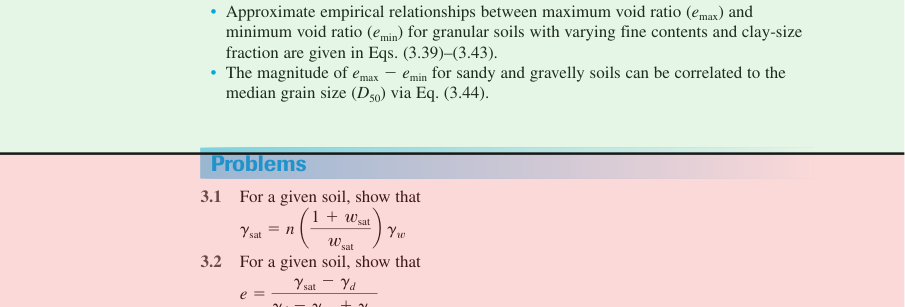

problems_02 - end boundary | PDF page 116 | y=551.78 | excluded above; retained below


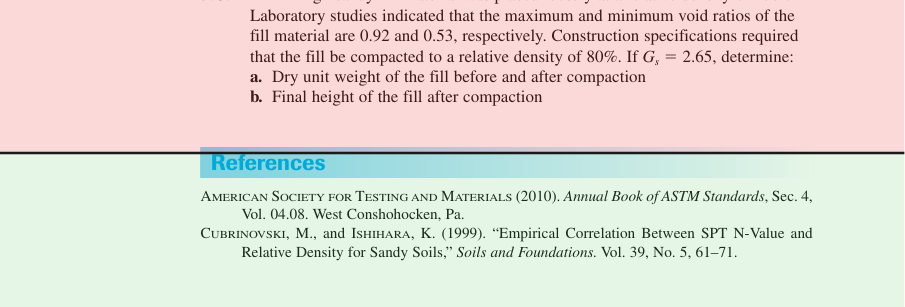

problems_06 - start boundary | PDF page 261 | y=138.04 | retained above; excluded below


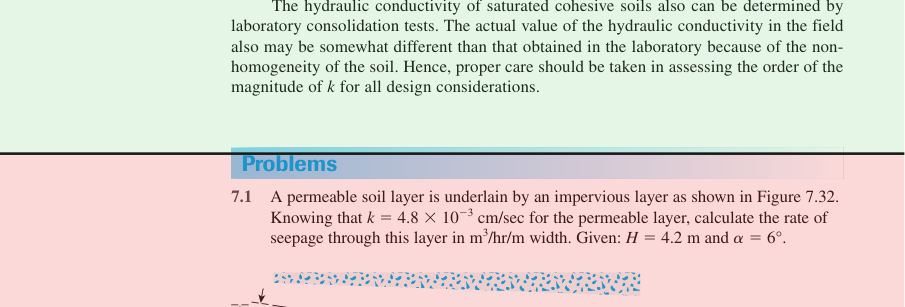

problems_06 - end boundary | PDF page 265 | y=354.05 | excluded above; retained below


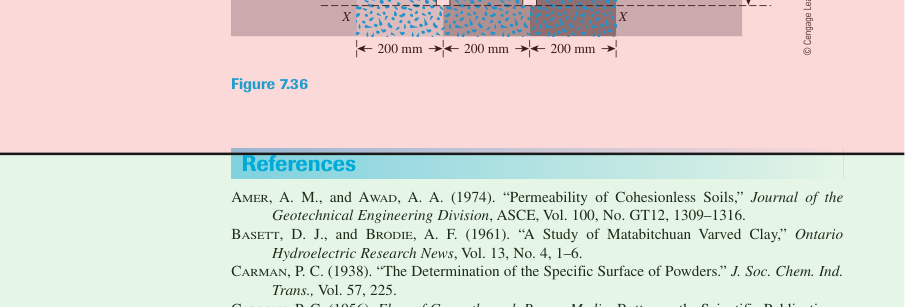

problems_09 - start boundary | PDF page 370 | y=50.41 | retained above; excluded below


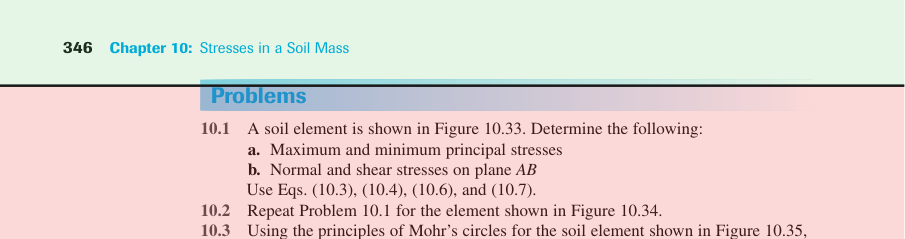

problems_09 - end boundary | PDF page 376 | y=50.41 | excluded above; retained below


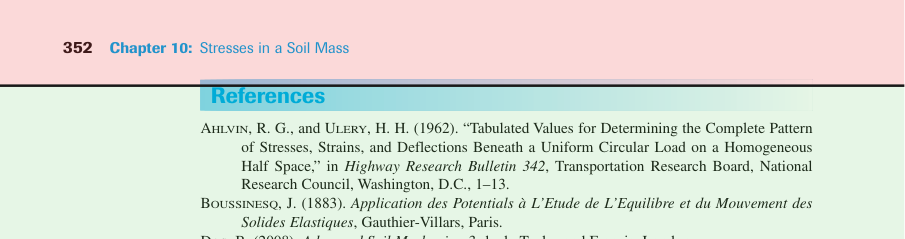

selected_answers - start boundary | PDF page 738 | y=178.08 | retained above; excluded below


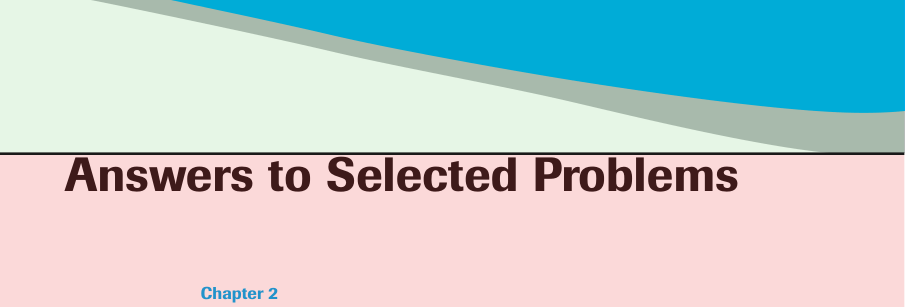

selected_answers - end boundary | PDF page 746 | y=178.08 | excluded above; retained below


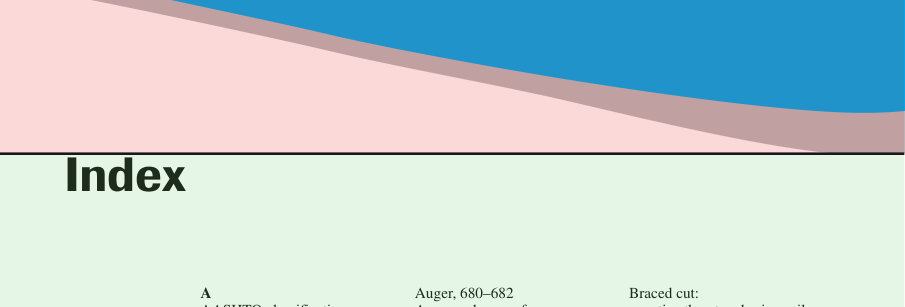

In [9]:
from IPython.display import Image, display


PREVIEW_BOUNDARIES = (
    ("problems_02", "start"),
    ("problems_02", "end"),
    ("problems_06", "start"),
    ("problems_06", "end"),
    ("problems_09", "start"),
    ("problems_09", "end"),
    ("selected_answers", "start"),
    ("selected_answers", "end"),
)

PREVIEW_MARGIN_POINTS = 90.0
PREVIEW_ZOOM = 1.7

RETAINED_FILL_COLOUR = (0.0, 0.65, 0.0)
EXCLUDED_FILL_COLOUR = (0.9, 0.0, 0.0)
BOUNDARY_LINE_COLOUR = (0.1, 0.1, 0.1)


def render_boundary_preview(
    pdf_document: pymupdf.Document,
    page_record: dict,
    boundary_y: float,
) -> bytes:
    """Render a coloured crop around one exclusion boundary."""

    page_index = page_record["pdf_page_index"]
    source_page = pdf_document.load_page(page_index)

    # Create a temporary in-memory page with the same dimensions.
    preview_document = pymupdf.open()

    try:
        preview_page = preview_document.new_page(
            width=source_page.rect.width,
            height=source_page.rect.height,
        )

        # Copy the original source page into the temporary document.
        preview_page.show_pdf_page(
            preview_page.rect,
            pdf_document,
            page_index,
        )

        # Shade every retained vertical region in green.
        for retained_y0, retained_y1 in (
            page_record["retained_y_intervals"]
        ):
            preview_page.draw_rect(
                pymupdf.Rect(
                    0.0,
                    retained_y0,
                    source_page.rect.width,
                    retained_y1,
                ),
                color=None,
                fill=RETAINED_FILL_COLOUR,
                fill_opacity=0.10,
                overlay=True,
            )

        # Shade every excluded vertical region in red.
        for excluded_y0, excluded_y1 in (
            page_record["excluded_y_intervals"]
        ):
            preview_page.draw_rect(
                pymupdf.Rect(
                    0.0,
                    excluded_y0,
                    source_page.rect.width,
                    excluded_y1,
                ),
                color=None,
                fill=EXCLUDED_FILL_COLOUR,
                fill_opacity=0.15,
                overlay=True,
            )

        # Draw the exact boundary across the page.
        preview_page.draw_line(
            pymupdf.Point(0.0, boundary_y),
            pymupdf.Point(
                source_page.rect.width,
                boundary_y,
            ),
            color=BOUNDARY_LINE_COLOUR,
            width=1.5,
            overlay=True,
        )

        # Limit the preview to the area around the boundary.
        preview_clip = pymupdf.Rect(
            0.0,
            max(
                0.0,
                boundary_y - PREVIEW_MARGIN_POINTS,
            ),
            source_page.rect.width,
            min(
                source_page.rect.height,
                boundary_y + PREVIEW_MARGIN_POINTS,
            ),
        )

        # Rasterise the preview without writing a file to disk.
        preview_pixmap = preview_page.get_pixmap(
            matrix=pymupdf.Matrix(
                PREVIEW_ZOOM,
                PREVIEW_ZOOM,
            ),
            clip=preview_clip,
            alpha=False,
        )

        return preview_pixmap.tobytes("png")

    finally:
        # Always release the temporary in-memory document.
        preview_document.close()


# Create lookups for the selected intervals and their pages.
exclusion_interval_by_id = {
    interval["section_id"]: interval
    for interval in exclusion_intervals
}

for section_id, boundary_side in PREVIEW_BOUNDARIES:
    interval = exclusion_interval_by_id[section_id]

    # Select the requested start or end boundary.
    if boundary_side == "start":
        page_index = interval["start_page_index"]
        boundary_y = interval["start_y"]
        boundary_description = (
            "retained above; excluded below"
        )
    elif boundary_side == "end":
        page_index = interval["end_page_index"]
        boundary_y = interval["end_y"]
        boundary_description = (
            "excluded above; retained below"
        )
    else:
        raise ValueError(
            f"Unknown boundary side: {boundary_side}"
        )

    page_record = page_geometry_by_index[page_index]

    print(
        f"{section_id} - {boundary_side} boundary | "
        f"PDF page {page_index + 1} | "
        f"y={boundary_y:.2f} | "
        f"{boundary_description}"
    )

    preview_png = render_boundary_preview(
        document,
        page_record,
        boundary_y,
    )

    display(Image(data=preview_png, format="png"))

The numerical and visual validation both passed. Every dark line is placed correctly, with no valid explanation, equation or reference cut in half.

Before extracting text, we should now define the final corpus scope. The best choice is:

* retain Chapters 1–17, their reference sections and Appendix A;
* exclude the front matter because it is not technical knowledge;
* exclude all pages from `Answers to Selected Problems` onwards, including the Index;
* keep benchmark questions and ground-truth answers in separate evaluation data, never in FAISS.

The Index is excluded because it contains keywords and page-number pointers rather than explanations. It could create misleading high-similarity retrieval results.

## Final knowledge-corpus scope

The RAG knowledge corpus is limited to the technical textbook material from Chapter 1 through Appendix A.

The final scope is:

- PDF pages 25–737: retained as the technical source range;
- PDF pages 1–24: excluded front matter;
- PDF pages 738–770: excluded selected answers, Index and trailing material.

Within the retained technical range, the validated chapter problem sections remain excluded using their page coordinates. Chapter references and Appendix A remain available as source material.

The evaluation questions and ground-truth answers will be managed as separate evaluation data. They must not be embedded or added to the FAISS knowledge index because this would create direct evaluation leakage.

In [10]:
# Define the final knowledge-corpus scope

FIRST_KNOWLEDGE_PDF_PAGE = 25
EXPECTED_APPENDIX_START_PAGE = 730
EXPECTED_ANSWER_TOC_PAGE = 738
EXPECTED_INDEX_TOC_PAGE = 746

LAST_KNOWLEDGE_PDF_PAGE = (
    EXPECTED_ANSWER_TOC_PAGE - 1
)


# Read the source PDF's internal table of contents.
toc_entries = document.get_toc(simple=True)


def find_unique_level_one_toc_entry(
    title_prefix: str,
) -> list:
    """Find one level-one PDF bookmark by its title prefix."""

    # Restrict the search to top-level document sections.
    matching_entries = [
        entry
        for entry in toc_entries
        if (
            entry[0] == 1
            and entry[1].strip().startswith(title_prefix)
        )
    ]

    # A missing or duplicated boundary would make the scope unsafe.
    if len(matching_entries) != 1:
        raise ValueError(
            "Expected one level-one TOC entry beginning with "
            f"{title_prefix!r}, found "
            f"{len(matching_entries)}."
        )

    return matching_entries[0]


# Locate the major document boundaries independently of the
# earlier coordinate-heading search.
chapter_one_toc_entry = (
    find_unique_level_one_toc_entry("Ch 1:")
)
appendix_toc_entry = (
    find_unique_level_one_toc_entry("Appendix - A")
)
answer_toc_entry = (
    find_unique_level_one_toc_entry(
        "Answers to Selected Problems"
    )
)
index_toc_entry = (
    find_unique_level_one_toc_entry("Index")
)

# Validate the bookmark page numbers against the observed layout.
assert (
    chapter_one_toc_entry[2]
    == FIRST_KNOWLEDGE_PDF_PAGE
)
assert (
    appendix_toc_entry[2]
    == EXPECTED_APPENDIX_START_PAGE
)
assert (
    answer_toc_entry[2]
    == EXPECTED_ANSWER_TOC_PAGE
)
assert (
    index_toc_entry[2]
    == EXPECTED_INDEX_TOC_PAGE
)

# Cross-check the last knowledge page against the previously
# validated unpaired Appendix References heading.
assert (
    EXPECTED_UNPAIRED_REFERENCE_PAGES[-1]
    == LAST_KNOWLEDGE_PDF_PAGE
)

# Create explicit, one-based page inventories for all three scopes.
front_matter_pages = tuple(
    range(
        1,
        FIRST_KNOWLEDGE_PDF_PAGE,
    )
)

knowledge_scope_pages = tuple(
    range(
        FIRST_KNOWLEDGE_PDF_PAGE,
        LAST_KNOWLEDGE_PDF_PAGE + 1,
    )
)

post_knowledge_pages = tuple(
    range(
        EXPECTED_ANSWER_TOC_PAGE,
        EXPECTED_PAGE_COUNT + 1,
    )
)

# Confirm that the three scopes partition all 770 pages exactly.
assert (
    front_matter_pages
    + knowledge_scope_pages
    + post_knowledge_pages
    == tuple(range(1, EXPECTED_PAGE_COUNT + 1))
)

print("Knowledge-corpus document scope: VALIDATED")
print(
    "First knowledge page:",
    FIRST_KNOWLEDGE_PDF_PAGE,
)
print(
    "Last knowledge page:",
    LAST_KNOWLEDGE_PDF_PAGE,
)
print(
    "Knowledge-scope pages:",
    len(knowledge_scope_pages),
)
print(
    "Excluded front-matter pages:",
    len(front_matter_pages),
)
print(
    "Excluded post-knowledge pages:",
    len(post_knowledge_pages),
)

Knowledge-corpus document scope: VALIDATED
First knowledge page: 25
Last knowledge page: 737
Knowledge-scope pages: 713
Excluded front-matter pages: 24
Excluded post-knowledge pages: 33


In [11]:
#Combine scope and problem exclusions

EXPECTED_KNOWLEDGE_STATE_COUNTS = Counter(
    {
        "fully_retained": 644,
        "fully_excluded": 37,
        "partially_retained": 32,
        "outside_knowledge_scope": 57,
    }
)


# Rebuild geometry using only the chapter-problem exclusions.
# Selected answers are now excluded through the wider scope rule.
problem_only_page_geometry = build_page_geometry(
    document,
    problem_exclusions,
)

knowledge_scope_page_set = set(
    knowledge_scope_pages
)
knowledge_page_geometry = []

for page_record in problem_only_page_geometry:
    # Copy the record so the exploratory geometry remains unchanged.
    knowledge_record = dict(page_record)
    pdf_page_number = knowledge_record[
        "pdf_page_number"
    ]

    # Fully remove every page outside the technical source range.
    if pdf_page_number not in knowledge_scope_page_set:
        knowledge_record["state"] = (
            "outside_knowledge_scope"
        )
        knowledge_record["excluded_y_intervals"] = [
            (
                0.0,
                knowledge_record["page_height"],
            )
        ]
        knowledge_record["retained_y_intervals"] = []

    knowledge_page_geometry.append(
        knowledge_record
    )

# Count every final corpus state.
knowledge_state_counts = Counter(
    page["state"]
    for page in knowledge_page_geometry
)

# Build the lookup that later extraction cells will use.
knowledge_page_geometry_by_index = {
    page["pdf_page_index"]: page
    for page in knowledge_page_geometry
}

# Validate the final partition.
assert (
    knowledge_state_counts
    == EXPECTED_KNOWLEDGE_STATE_COUNTS
)
assert (
    sum(knowledge_state_counts.values())
    == EXPECTED_PAGE_COUNT
)

# Confirm that no evaluation-answer or Index page is retained.
assert all(
    knowledge_page_geometry[
        pdf_page_number - 1
    ]["state"] == "outside_knowledge_scope"
    for pdf_page_number in post_knowledge_pages
)

# Confirm that all 32 problem boundaries remain partial pages.
expected_problem_boundary_pages = set(
    (
        *EXPECTED_PROBLEM_PAGES,
        *EXPECTED_REFERENCE_PAGES,
    )
)

actual_problem_boundary_pages = {
    page["pdf_page_number"]
    for page in knowledge_page_geometry
    if page["state"] == "partially_retained"
}

assert (
    actual_problem_boundary_pages
    == expected_problem_boundary_pages
)

print("Final knowledge geometry: PASSED")

for page_state in (
    "fully_retained",
    "fully_excluded",
    "partially_retained",
    "outside_knowledge_scope",
):
    print(
        f"  {page_state:<24}: "
        f"{knowledge_state_counts[page_state]}"
    )

Final knowledge geometry: PASSED
  fully_retained          : 644
  fully_excluded          : 37
  partially_retained      : 32
  outside_knowledge_scope : 57


Both checks passed exactly.

We should now perform raw positioned extraction without cleaning anything yet. This lets us inspect running headers, printed page numbers and formula-encoding characters before deciding how to remove or repair them.

## Raw positioned-text extraction

This stage extracts text only from the validated retained regions. No textual cleaning, header removal, formula repair, chunking or file writing is performed yet.

Each extracted line keeps its PDF page number and bounding box. Retaining positional metadata is necessary because structural elements such as running headers and printed page numbers should be identified using both their content and physical position, rather than unreliable text-only rules.

The function returns standard Python dictionaries, lists, strings and numbers so that it can later be moved into a preprocessing module or exposed through an API without depending on notebook-specific display behaviour.

In [12]:
# Only ordinary textual whitespace may be removed from line edges.
#
# Python's unrestricted ``str.strip()`` also removes some C0 control
# characters, such as vertical tab and form feed. In this PDF, those
# control codes may represent visible mathematical glyphs. Removing
# them before investigation could silently corrupt equations.
TEXT_EDGE_WHITESPACE = " \t\r\n"


def trim_text_edges(text: str) -> str:
    """
    Remove conventional layout whitespace from a text line.

    Mathematical control codes are deliberately preserved. Keeping
    this behaviour in one function ensures that notebook extraction
    and the future preprocessing/API implementation use exactly the
    same text-normalisation contract.
    """

    return text.strip(TEXT_EDGE_WHITESPACE)

def extract_positioned_lines_from_page(
    pdf_document: pymupdf.Document,
    page_record: dict,
) -> dict:
    """
    Extract positioned text from one page's retained regions.

    Parameters
    ----------
    pdf_document:
        Open PyMuPDF document containing the verified source PDF.

    page_record:
        Page-level geometry record created by
        ``build_page_geometry``. It must contain the PDF page
        index, page number, page state and retained y-intervals.

    Returns
    -------
    dict
        A serialisable page record containing ordered text lines,
        page provenance and bounding boxes.

        Fully excluded and out-of-scope pages return an empty
        ``lines`` list rather than being omitted. Keeping them in
        the inventory preserves a complete audit trail across all
        770 source pages.

    Notes
    -----
    This function deliberately performs no semantic cleaning.
    Running headers, printed page numbers and unusual formula
    characters remain available for later inspection.
    """

    # Read the page identifiers from the validated geometry.
    page_index = page_record["pdf_page_index"]
    pdf_page_number = page_record["pdf_page_number"]

    # Reject a page record that does not correspond to the document.
    if not 0 <= page_index < pdf_document.page_count:
        raise IndexError(
            f"PDF page index is outside the document: "
            f"{page_index}"
        )

    source_page = pdf_document.load_page(page_index)

    # Confirm that the geometry was created for this exact page size.
    if not isclose(
        float(source_page.rect.width),
        page_record["page_width"],
        rel_tol=0.0,
        abs_tol=COORDINATE_TOLERANCE,
    ):
        raise ValueError(
            f"Page-width mismatch on PDF page "
            f"{pdf_page_number}."
        )

    if not isclose(
        float(source_page.rect.height),
        page_record["page_height"],
        rel_tol=0.0,
        abs_tol=COORDINATE_TOLERANCE,
    ):
        raise ValueError(
            f"Page-height mismatch on PDF page "
            f"{pdf_page_number}."
        )

    positioned_lines = []

    # Extract each retained region separately. This prevents text
    # from an excluded problem section entering the page record.
    for region_index, (
        retained_y0,
        retained_y1,
    ) in enumerate(page_record["retained_y_intervals"]):
        retained_clip = pymupdf.Rect(
            0.0,
            retained_y0,
            source_page.rect.width,
            retained_y1,
        )

        # Dictionary extraction preserves blocks, lines, spans and
        # bounding boxes while ``sort=True`` requests visual order.
        region_dictionary = source_page.get_text(
            "dict",
            clip=retained_clip,
            sort=True,
        )

        # Process only text blocks. Image blocks are outside the
        # current text-only baseline and will be assessed separately.
        for block_order, block in enumerate(
            region_dictionary.get("blocks", [])
        ):
            if block.get("type") != 0:
                continue

            # Preserve the source block number where PyMuPDF provides it.
            block_number = block.get(
                "number",
                block_order,
            )

            for line_number, line in enumerate(
                block.get("lines", [])
            ):
                # Join the original spans without inserting artificial
                # spaces that could change equations or punctuation.
                
                #----------------------------------------
                #line_text = "".join(
                #    span.get("text", "")
                #    for span in line.get("spans", [])
                #).strip()
                # this was replaced by the next lines in step 1.30 to rectify its code
                #----------------------------------------
                
                ##
                # Reconstruct the source line without introducing new characters.
                raw_line_text = "".join(
                    span.get("text", "")
                    for span in line.get("spans", [])
                )

                # Remove only normal layout whitespace. Mathematical control codes
                # remain available for the later font-aware investigation.
                line_text = trim_text_edges(raw_line_text)
                ##
                
                # Empty graphical or formatting lines have no RAG value.
                if not line_text:
                    continue

                # Convert PyMuPDF coordinates to ordinary floats so that
                # the record can later be serialised as JSON.
                line_bbox = tuple(
                    float(coordinate)
                    for coordinate in line["bbox"]
                )

                positioned_lines.append(
                    {
                        "text": line_text,
                        "bbox": line_bbox,
                        "region_index": region_index,
                        "block_number": block_number,
                        "line_number": line_number,
                        "span_count": len(
                            line.get("spans", [])
                        ),
                    }
                )

    # Join lines only for exploratory counts and previews.
    # The positioned line records remain the authoritative output.
    page_text = "\n".join(
        line["text"]
        for line in positioned_lines
    )

    return {
        "pdf_page_index": page_index,
        "pdf_page_number": pdf_page_number,
        "page_state": page_record["state"],
        "page_width": page_record["page_width"],
        "page_height": page_record["page_height"],
        "retained_regions": list(
            page_record["retained_y_intervals"]
        ),
        "lines": positioned_lines,
        "text": page_text,
        "line_count": len(positioned_lines),
        "character_count": len(page_text),
    }


# Extract every source page so that excluded and retained pages
# remain represented in the same auditable inventory.
raw_extracted_pages = [
    extract_positioned_lines_from_page(
        pdf_document=document,
        page_record=page_record,
    )
    for page_record in knowledge_page_geometry
]

# Calculate initial extraction totals without modifying the text.
pages_with_raw_text = sum(
    bool(page["lines"])
    for page in raw_extracted_pages
)
raw_line_count = sum(
    page["line_count"]
    for page in raw_extracted_pages
)
raw_character_count = sum(
    page["character_count"]
    for page in raw_extracted_pages
)

# Validate the fixed page-level results.
assert len(raw_extracted_pages) == EXPECTED_PAGE_COUNT
assert pages_with_raw_text == 676

# Excluded pages must not contain extracted text.
assert all(
    not page["lines"]
    for page in raw_extracted_pages
    if page["page_state"] in {
        "fully_excluded",
        "outside_knowledge_scope",
    }
)

print("Raw positioned-text extraction: COMPLETE")
print(
    "Source page records:",
    len(raw_extracted_pages),
)
print(
    "Pages containing retained text:",
    pages_with_raw_text,
)
print(
    "Extracted positioned lines:",
    raw_line_count,
)
print(
    "Extracted characters:",
    raw_character_count,
)

Raw positioned-text extraction: COMPLETE
Source page records: 770
Pages containing retained text: 676
Extracted positioned lines: 41672
Extracted characters: 881391


In [13]:
# Open the exact textbook used by the thesis extraction pipeline.
audit_document = pymupdf.open(
    "../data/raw/corpus/das-sobhan-principles-geotechnical-engineering-8e-si.pdf"
)

# Define the zero-based PDF page index for frozen audit Case B.
case_b_page_index = 194

# Load the visible source page so its exact dimensions can be checked.
audit_page = audit_document.load_page(case_b_page_index)

# Retrieve the existing geometry record that was already created for this exact PDF page.
case_b_page_record = dict(
    knowledge_page_geometry[case_b_page_index]
)

# Confirm that the geometry record really corresponds to frozen audit Case B.
assert (
    case_b_page_record["pdf_page_index"]
    == case_b_page_index
)

# Confirm that the human-readable PDF page number is 195.
assert (
    case_b_page_record["pdf_page_number"]
    == 195
)

# Replace the normal retained intervals with one full-page interval for this diagnostic only.
# This prevents corpus exclusion rules from affecting the parser comparison.
case_b_page_record["retained_y_intervals"] = [
    (
        0.0,
        float(audit_page.rect.height),
    )
]

# Mark this temporary record clearly as an audit record rather than production geometry.
case_b_page_record["state"] = "audit_full_page"

# Run the exact existing positioned extraction function without modifying its implementation.
positioned_case_b = extract_positioned_lines_from_page(
    pdf_document=audit_document,
    page_record=case_b_page_record,
)

# Print a heading for the diagnostic output.
print(
    "Existing positioned PyMuPDF extraction for Case B:\n"
)

# Iterate through the authoritative positioned line records returned by the extractor.
for line in positioned_case_b["lines"]:
    # Print each line with repr so invisible mathematical control characters remain visible.
    print(repr(line["text"]))

# Close the diagnostic PDF after extraction is complete.
audit_document.close()

Existing positioned PyMuPDF extraction for Case B:

'6.10 Specifications for Field Compaction'
'171'
'reach maximum values at a depth of about 0.5 m and gradually decrease at lesser depths.'
'This decrease occurs because of the lack of confining pressure toward the surface. Once'
'the relationship between depth and relative density (or dry unit weight) for a given soil'
'with a given number of roller passes is determined, estimating the approximate thickness'
'of each lift is easy. This procedure is shown in Figure 6.21b (D’Appolonia et al., 1969).'
'6.10 Specifications for Field Compaction'
'In most specifications for earthwork, the contractor is instructed to achieve a compacted'
'field dry unit weight of 90 to 95% of the maximum dry unit weight determined in the lab-'
'oratory by either the standard or modified Proctor test. This is a specification for relative'
'compaction, which can be expressed as'
'\x04 100'
'(6.19)'
'R1%2 \x02'
'gd1field2'
'gd1max—lab2'
'where R \x02 relative c

The line and character counts are exploratory.

## Structural-noise and character inventory

The raw extraction still contains structural text such as running headers and some printed page numbers.

Lines fully contained above 40 points are inventoried as running-header candidates. Lines beginning at or below 608 points are inventoried for bottom-of-page inspection, but they are not automatically classified as noise because valid equations, figure captions and reference entries can also occur near the bottom of a page.

Non-whitespace control characters are counted separately. These characters may represent mathematical symbols whose PDF font encoding was not translated correctly. They must be investigated rather than deleted blindly.

In [14]:
from collections import Counter


RUNNING_HEADER_BOTTOM_Y = 40.0
BOTTOM_INSPECTION_TOP_Y = 608.0

# Standard whitespace controls are valid text formatting and should
# not be confused with unexpected PDF font-encoding characters.
STANDARD_WHITESPACE_CONTROLS = {
    "\n",
    "\r",
    "\t",
}


def classify_line_vertical_zone(
    line_record: dict,
) -> str:
    """
    Classify one positioned line by its vertical page location.

    This is an inventory function, not a cleaning function. In
    particular, bottom-zone text is not automatically removed.
    """

    # Bounding-box order is x0, y0, x1, y1.
    _, line_y0, _, line_y1 = line_record["bbox"]

    # Only lines fully contained in the established top band are
    # treated as running-header candidates.
    if line_y1 <= RUNNING_HEADER_BOTTOM_Y:
        return "running_header_candidate"

    # The bottom band requires later content-and-position inspection.
    if line_y0 >= BOTTOM_INSPECTION_TOP_Y:
        return "bottom_inspection_candidate"

    return "body_candidate"


# Count all extracted lines by their observed page zone.
vertical_zone_counts = Counter(
    classify_line_vertical_zone(line)
    for page in raw_extracted_pages
    for line in page["lines"]
)

# Count unexpected control characters across the raw retained text.
control_character_counts = Counter(
    character
    for page in raw_extracted_pages
    for character in page["text"]
    if (
        ord(character) < 32
        and character
        not in STANDARD_WHITESPACE_CONTROLS
    )
)

# Count how many pages contain candidate structural lines.
pages_with_header_candidates = sum(
    any(
        classify_line_vertical_zone(line)
        == "running_header_candidate"
        for line in page["lines"]
    )
    for page in raw_extracted_pages
)

pages_with_bottom_candidates = sum(
    any(
        classify_line_vertical_zone(line)
        == "bottom_inspection_candidate"
        for line in page["lines"]
    )
    for page in raw_extracted_pages
)

print("Vertical line-zone inventory:")

for zone_name in (
    "running_header_candidate",
    "body_candidate",
    "bottom_inspection_candidate",
):
    print(
        f"  {zone_name:<29}: "
        f"{vertical_zone_counts[zone_name]}"
    )

print(
    "Pages with header candidates:",
    pages_with_header_candidates,
)
print(
    "Pages with bottom candidates:",
    pages_with_bottom_candidates,
)

print("\nNon-whitespace control-character inventory:")

if not control_character_counts:
    print("  None detected")
else:
    # Display Unicode code points rather than printing invisible
    # control characters directly into the notebook.
    for character, count in sorted(
        control_character_counts.items(),
        key=lambda item: ord(item[0]),
    ):
        print(
            f"  U+{ord(character):04X}: {count}"
        )

Vertical line-zone inventory:
  running_header_candidate     : 1263
  body_candidate               : 40222
  bottom_inspection_candidate  : 187
Pages with header candidates: 629
Pages with bottom candidates: 133

Non-whitespace control-character inventory:
  U+0002: 4015
  U+0003: 2486
  U+0004: 1384
  U+0005: 801
  U+0006: 388
  U+0007: 416
  U+0008: 202
  U+000B: 85
  U+000C: 34
  U+000E: 21
  U+000F: 3
  U+0010: 1


In [15]:
REPRESENTATIVE_EXTRACTION_PAGES = (
    25,
    114,
    116,
    261,
    265,
    370,
    376,
    737,
)


def print_positioned_line_sample(
    page_record: dict,
    sample_size: int = 3,
) -> None:
    """
    Print the first and final positioned lines from one page.

    This helper is only for notebook inspection. Production code
    will consume the returned dictionaries directly.
    """

    print(
        f"\nPDF page {page_record['pdf_page_number']} | "
        f"state={page_record['page_state']} | "
        f"lines={page_record['line_count']}"
    )

    # Avoid duplicated output when a page has few lines.
    if page_record["line_count"] <= sample_size * 2:
        sampled_lines = page_record["lines"]
    else:
        sampled_lines = [
            *page_record["lines"][:sample_size],
            *page_record["lines"][-sample_size:],
        ]

    for line in sampled_lines:
        rounded_bbox = tuple(
            round(coordinate, 2)
            for coordinate in line["bbox"]
        )

        print(
            f"  bbox={rounded_bbox} | "
            f"{line['text']!r}"
        )


# Use zero-based list access only after converting the one-based
# PDF page number explicitly.
for pdf_page_number in REPRESENTATIVE_EXTRACTION_PAGES:
    print_positioned_line_sample(
        raw_extracted_pages[pdf_page_number - 1]
    )


PDF page 25 | state=fully_retained | lines=29
  bbox=(462.97, 54.24, 495.03, 109.24) | '1'
  bbox=(314.82, 84.91, 435.51, 100.91) | 'C H A P T E R'
  bbox=(56.02, 146.09, 409.58, 174.09) | 'Geotechnical Engineering—'
  bbox=(136.02, 572.74, 496.03, 582.74) | '(Yellow River, China), and the Indus (India). Dykes dating back to about 2000 B.C. were'
  bbox=(136.02, 584.74, 496.08, 594.74) | 'built in the basin of the Indus to protect the town of Mohenjo Dara (in what became'
  bbox=(490.77, 612.38, 496.02, 621.38) | '1'

PDF page 114 | state=partially_retained | lines=25
  bbox=(37.0, 23.31, 48.65, 33.31) | '90'
  bbox=(58.65, 24.08, 218.51, 33.08) | 'Chapter 3: Weight–Volume Relationships'
  bbox=(117.84, 46.04, 206.19, 60.04) | '3.9 Summary'
  bbox=(132.85, 349.25, 292.82, 359.25) | 'fraction are given in Eqs. (3.39)–(3.43).'
  bbox=(123.85, 360.88, 462.18, 373.25) | '• The magnitude of emax \x04 emin for sandy and gravelly soils can be correlated to the'
  bbox=(132.85, 373.15, 290.23

The results will determine a safe header/page-number rule and how we investigate the encoded mathematical symbols.

The extraction results are consistent and the methodology is working. The next safe action is to remove only proven structural noise while keeping all formula control characters unchanged.

## Source-specific structural cleaning

The textbook uses repeated running headers above 40 points. These headers contain printed page numbers, chapter names, section names and occasionally the word `Problems`. They are structural navigation elements rather than knowledge content.

Some chapter-opening pages place the printed page number near the bottom instead. A bottom line is removed only when all of the following conditions are satisfied:

- it begins at or below 608 points;
- it is positioned at the outer left or right page edge;
- its text exactly matches the printed textbook page number expected from the PDF-page offset.

This combined rule avoids deleting valid reference entries, equations, tables or figure captions near the bottom of a page.

No mathematical control characters are repaired or deleted during this stage.

In [16]:
PRINTED_PAGE_NUMBER_BOTTOM_Y = 608.0
PRINTED_PAGE_NUMBER_EDGE_WIDTH = 60.0

# PDF page 25 is printed textbook page 1. Therefore, the
# printed page number is always the PDF page number minus 24.
PRINTED_TO_PDF_PAGE_OFFSET = (
    FIRST_KNOWLEDGE_PDF_PAGE - 1
)


def expected_printed_page_number(
    pdf_page_number: int,
) -> str:
    """
    Return the expected printed textbook page number.

    The result is returned as text because it will be compared
    directly with an extracted line.
    """

    printed_page_number = (
        pdf_page_number
        - PRINTED_TO_PDF_PAGE_OFFSET
    )

    return str(printed_page_number)


def is_running_header_line(
    line_record: dict,
) -> bool:
    """
    Identify a line fully contained in the running-header band.

    The 40-point boundary was established from the earlier heading
    inventory and visual inspection of the verified source PDF.
    """

    # Bounding-box order is x0, y0, x1, y1.
    line_y1 = line_record["bbox"][3]

    return line_y1 <= RUNNING_HEADER_BOTTOM_Y


def is_bottom_printed_page_number(
    line_record: dict,
    pdf_page_number: int,
    page_width: float,
) -> bool:
    """
    Identify a bottom printed page number using three conditions.

    A line is removed only when its position, expected value and
    outer-edge placement all agree. This prevents broad coordinate
    filtering from deleting valid bottom-of-page content.
    """

    line_x0, line_y0, line_x1, _ = (
        line_record["bbox"]
    )

    # Test whether the line is within the bottom inspection zone.
    is_in_bottom_zone = (
        line_y0 >= PRINTED_PAGE_NUMBER_BOTTOM_Y
    )

    # Printed page numbers alternate between the outer page edges.
    is_at_left_edge = (
        line_x1 <= PRINTED_PAGE_NUMBER_EDGE_WIDTH
    )
    is_at_right_edge = (
        line_x0
        >= page_width
        - PRINTED_PAGE_NUMBER_EDGE_WIDTH
    )
    is_at_outer_edge = (
        is_at_left_edge or is_at_right_edge
    )

    # Validate the extracted text against the known PDF-to-book
    # page-number relationship.
    has_expected_value = (
        line_record["text"]
        == expected_printed_page_number(
            pdf_page_number
        )
    )

    return (
        is_in_bottom_zone
        and is_at_outer_edge
        and has_expected_value
    )


def classify_structural_line(
    line_record: dict,
    pdf_page_number: int,
    page_width: float,
) -> str:
    """
    Classify one line as retained or structural noise.

    The returned reason can be logged by a preprocessing service,
    stored in an audit file or exposed through a diagnostic API.
    """

    if is_running_header_line(line_record):
        return "remove_running_header"

    if is_bottom_printed_page_number(
        line_record=line_record,
        pdf_page_number=pdf_page_number,
        page_width=page_width,
    ):
        return "remove_bottom_page_number"

    return "retain"


def remove_structural_lines_from_page(
    raw_page_record: dict,
) -> dict:
    """
    Remove validated structural lines from one extracted page.

    This function does not mutate the raw page record. It returns a
    new record containing retained lines and an audit inventory of
    every removed line and its removal reason.
    """

    pdf_page_number = raw_page_record[
        "pdf_page_number"
    ]
    page_width = raw_page_record["page_width"]

    retained_lines = []
    removed_structural_lines = []

    # Classify each positioned line independently.
    for line_record in raw_page_record["lines"]:
        structural_decision = classify_structural_line(
            line_record=line_record,
            pdf_page_number=pdf_page_number,
            page_width=page_width,
        )

        if structural_decision == "retain":
            # Copy the dictionary to avoid changing raw extraction.
            retained_lines.append(dict(line_record))
        else:
            # Preserve removed content for methodological auditing.
            removed_structural_lines.append(
                {
                    **line_record,
                    "removal_reason": (
                        structural_decision
                    ),
                }
            )

    # Reconstruct exploratory page text from retained lines only.
    cleaned_page_text = "\n".join(
        line["text"]
        for line in retained_lines
    )

    # Copy page-level provenance without retaining duplicate raw data.
    cleaned_page_record = {
        key: value
        for key, value in raw_page_record.items()
        if key not in {
            "lines",
            "text",
            "line_count",
            "character_count",
        }
    }

    cleaned_page_record.update(
        {
            "lines": retained_lines,
            "text": cleaned_page_text,
            "line_count": len(retained_lines),
            "character_count": len(
                cleaned_page_text
            ),
            "removed_structural_lines": (
                removed_structural_lines
            ),
            "removed_structural_line_count": len(
                removed_structural_lines
            ),
        }
    )

    return cleaned_page_record


# Apply the pure page-cleaning function to every source record.
structurally_clean_pages = [
    remove_structural_lines_from_page(page)
    for page in raw_extracted_pages
]

# Count removal decisions across the full textbook.
structural_removal_counts = Counter(
    removed_line["removal_reason"]
    for page in structurally_clean_pages
    for removed_line
    in page["removed_structural_lines"]
)

cleaned_line_count = sum(
    page["line_count"]
    for page in structurally_clean_pages
)
cleaned_character_count = sum(
    page["character_count"]
    for page in structurally_clean_pages
)
pages_with_cleaned_text = sum(
    bool(page["lines"])
    for page in structurally_clean_pages
)

# Identify pages that contained only structural text after geometric
# problem removal. Empty output is correct for these pages.
pages_emptied_by_structural_cleaning = [
    cleaned_page["pdf_page_number"]
    for raw_page, cleaned_page in zip(
        raw_extracted_pages,
        structurally_clean_pages,
    )
    if (
        raw_page["lines"]
        and not cleaned_page["lines"]
    )
]

# Count exact boundary-heading lines remaining after cleaning.
retained_boundary_heading_counts = Counter(
    line["text"]
    for page in structurally_clean_pages
    for line in page["lines"]
    if line["text"] in TARGET_HEADINGS
)

# Count valid lines that remain in the bottom inspection zone.
retained_bottom_zone_lines = sum(
    line["bbox"][1]
    >= BOTTOM_INSPECTION_TOP_Y
    for page in structurally_clean_pages
    for line in page["lines"]
)

# Validate the known source-specific cleaning result.
assert structural_removal_counts == Counter(
    {
        "remove_running_header": 1263,
        "remove_bottom_page_number": 39,
    }
)
assert cleaned_line_count == 40_370
assert pages_with_cleaned_text == 670
assert pages_emptied_by_structural_cleaning == [
    87,
    144,
    370,
    445,
    509,
    727,
]

# Every top running-header candidate must now be absent.
assert all(
    not is_running_header_line(line)
    for page in structurally_clean_pages
    for line in page["lines"]
)

# No recognised bottom page number may remain.
assert all(
    not is_bottom_printed_page_number(
        line_record=line,
        pdf_page_number=page[
            "pdf_page_number"
        ],
        page_width=page["page_width"],
    )
    for page in structurally_clean_pages
    for line in page["lines"]
)

# Problems, selected answers and Index must remain absent.
# The 18 technical References headings should remain available.
assert retained_boundary_heading_counts == Counter(
    {
        "References": 18,
    }
)

# Confirm the accounting relationship between raw and cleaned lines.
assert (
    cleaned_line_count
    + sum(structural_removal_counts.values())
    == raw_line_count
)

print("Structural-text cleaning: PASSED")
print(
    "Removed running-header lines:",
    structural_removal_counts[
        "remove_running_header"
    ],
)
print(
    "Removed bottom page numbers:",
    structural_removal_counts[
        "remove_bottom_page_number"
    ],
)
print(
    "Retained bottom-zone lines:",
    retained_bottom_zone_lines,
)
print(
    "Cleaned positioned lines:",
    cleaned_line_count,
)
print(
    "Cleaned characters:",
    cleaned_character_count,
)
print(
    "Pages containing cleaned text:",
    pages_with_cleaned_text,
)
print(
    "Pages emptied by structural cleaning:",
    pages_emptied_by_structural_cleaning,
)
print(
    "Retained boundary headings:",
    dict(retained_boundary_heading_counts),
)

Structural-text cleaning: PASSED
Removed running-header lines: 1263
Removed bottom page numbers: 39
Retained bottom-zone lines: 148
Cleaned positioned lines: 40370
Cleaned characters: 853814
Pages containing cleaned text: 670
Pages emptied by structural cleaning: [87, 144, 370, 445, 509, 727]
Retained boundary headings: {'References': 18}


## Formula-character inventory by embedded font

The unexpected control characters originate from mathematical fonts embedded in the textbook PDF.

A control code cannot safely be replaced based only on its Unicode code point. The same extracted code may correspond to different visible symbols when it originates from a different embedded font.

The following investigation re-reads the retained PDF regions, applies the same structural-cleaning rules and records each control-character occurrence together with:

- its embedded font;
- PDF page;
- line context;
- line and span coordinates;
- font size and span flags.

No replacement is performed. The purpose is to establish an evidence-based mapping strategy before formula normalisation.

In [17]:
def is_unexpected_control_character(
    character: str,
) -> bool:
    """
    Return whether a character is an unexpected text control.

    Newlines, carriage returns and tabs remain legitimate formatting
    characters and are therefore excluded from this classification.
    """

    return (
        ord(character) < 32
        and character
        not in STANDARD_WHITESPACE_CONTROLS
    )


def collect_control_character_occurrences(
    pdf_document: pymupdf.Document,
    page_geometry_records: list[dict],
) -> list[dict]:
    """
    Collect font-aware control-character occurrences.

    Parameters
    ----------
    pdf_document:
        Open and previously verified source PDF.

    page_geometry_records:
        Final knowledge-corpus page geometry containing only the
        retained regions that may enter later preprocessing.

    Returns
    -------
    list[dict]
        One serialisable record per control-character occurrence.
        Repeated characters are recorded separately because frequency
        is part of the extraction-quality assessment.
    """

    occurrences = []

    for page_record in page_geometry_records:
        page_index = page_record["pdf_page_index"]
        pdf_page_number = page_record[
            "pdf_page_number"
        ]

        # Pages without retained regions require no extraction call.
        if not page_record["retained_y_intervals"]:
            continue

        source_page = pdf_document.load_page(page_index)

        for region_index, (
            retained_y0,
            retained_y1,
        ) in enumerate(
            page_record["retained_y_intervals"]
        ):
            retained_clip = pymupdf.Rect(
                0.0,
                retained_y0,
                source_page.rect.width,
                retained_y1,
            )

            # Span-level dictionary extraction exposes the font name
            # associated with each encoded character.
            region_dictionary = source_page.get_text(
                "dict",
                clip=retained_clip,
                sort=True,
            )

            for block_order, block in enumerate(
                region_dictionary.get("blocks", [])
            ):
                if block.get("type") != 0:
                    continue

                block_number = block.get(
                    "number",
                    block_order,
                )

                for line_number, line in enumerate(
                    block.get("lines", [])
                ):
                    #------------------------------------
                    #line_text = "".join(
                    #    span.get("text", "")
                    #    for span in line.get(
                    #        "spans",
                    #        [],
                    #    )
                    #).strip()
                    # this was replaced by the next lines in step 1.30 to rectify its code
                    #------------------------------------
                    
                    ##
                    # Reconstruct the same character stream used by page extraction.
                    raw_line_text = "".join(
                        span.get("text", "")
                        for span in line.get(
                            "spans",
                            [],
                        )
                    )

                    # Apply the shared trimming contract so the two inventories are
                    # directly comparable.
                    line_text = trim_text_edges(raw_line_text)
                    ##
                    
                    if not line_text:
                        continue

                    line_bbox = tuple(
                        float(coordinate)
                        for coordinate in line["bbox"]
                    )

                    # Apply exactly the same structural decision used
                    # for the cleaned page records.
                    structural_decision = (
                        classify_structural_line(
                            line_record={
                                "text": line_text,
                                "bbox": line_bbox,
                            },
                            pdf_page_number=(
                                pdf_page_number
                            ),
                            page_width=float(
                                source_page.rect.width
                            ),
                        )
                    )

                    if structural_decision != "retain":
                        continue

                    for span in line.get("spans", []):
                        span_text = span.get(
                            "text",
                            "",
                        )
                        span_font = span.get(
                            "font",
                            "UNKNOWN_FONT",
                        )
                        span_bbox = tuple(
                            float(coordinate)
                            for coordinate
                            in span["bbox"]
                        )

                        # Record each control character independently.
                        for character in span_text:
                            if not (
                                is_unexpected_control_character(
                                    character
                                )
                            ):
                                continue

                            occurrences.append(
                                {
                                    "code_point": (
                                        f"U+{ord(character):04X}"
                                    ),
                                    "ordinal": ord(
                                        character
                                    ),
                                    "font": span_font,
                                    "font_size": float(
                                        span.get(
                                            "size",
                                            0.0,
                                        )
                                    ),
                                    "span_flags": int(
                                        span.get(
                                            "flags",
                                            0,
                                        )
                                    ),
                                    "pdf_page_index": (
                                        page_index
                                    ),
                                    "pdf_page_number": (
                                        pdf_page_number
                                    ),
                                    "region_index": (
                                        region_index
                                    ),
                                    "block_number": (
                                        block_number
                                    ),
                                    "line_number": (
                                        line_number
                                    ),
                                    "line_text": (
                                        line_text
                                    ),
                                    "line_bbox": (
                                        line_bbox
                                    ),
                                    "span_bbox": (
                                        span_bbox
                                    ),
                                }
                            )

    return occurrences


# Build the font-aware occurrence inventory without changing text.
control_character_occurrences = (
    collect_control_character_occurrences(
        pdf_document=document,
        page_geometry_records=(
            knowledge_page_geometry
        ),
    )
)

# Aggregate by both embedded font and extracted control code.
font_control_counts = Counter(
    (
        occurrence["font"],
        occurrence["code_point"],
    )
    for occurrence
    in control_character_occurrences
)

#----------------------------------------------------------------------
# The structural lines contained no formula control characters, so
# the occurrence total should match the earlier raw inventory.
#assert len(control_character_occurrences) == sum(
#    control_character_counts.values()
#)
# this was replaced by the next lines in step 1.30 to rectify its code
#----------------------------------------------------------------------

##
# Count control characters in the structurally cleaned text. This is
# the correct comparison target because the font-aware inventory also
# excludes running headers and printed page numbers.
cleaned_control_character_counts = Counter(
    character
    for page in structurally_clean_pages
    for character in page["text"]
    if is_unexpected_control_character(character)
)

# Count control characters contained in the removed structural lines.
# These remain documented even though they will not enter the corpus.
removed_structural_control_counts = Counter(
    character
    for page in structurally_clean_pages
    for removed_line
    in page["removed_structural_lines"]
    for character in removed_line["text"]
    if is_unexpected_control_character(character)
)

# Raw controls must equal the controls retained after cleaning plus
# those found in removed structural lines.
reconstructed_raw_control_counts = (
    cleaned_control_character_counts
    + removed_structural_control_counts
)

assert (
    reconstructed_raw_control_counts
    == control_character_counts
)

# Convert the cleaned character inventory to the same U+XXXX format
# used by the font-aware occurrence records.
cleaned_code_point_counts = Counter(
    {
        f"U+{ord(character):04X}": count
        for character, count
        in cleaned_control_character_counts.items()
    }
)

font_aware_code_point_counts = Counter(
    occurrence["code_point"]
    for occurrence
    in control_character_occurrences
)

# This exact per-code comparison is stronger than comparing only the
# two totals. It detects a missing or duplicated individual symbol.
assert (
    font_aware_code_point_counts
    == cleaned_code_point_counts
)

print("Control-character accounting: PASSED")
print(
    "Raw control-character occurrences:",
    sum(control_character_counts.values()),
)
print(
    "Controls removed with structural lines:",
    sum(
        removed_structural_control_counts.values()
    ),
)
print(
    "Controls retained after structural cleaning:",
    sum(cleaned_control_character_counts.values()),
)
print(
    "Font-aware occurrences:",
    len(control_character_occurrences),
)
##

print(
    "Font-control groups:",
    len(font_control_counts),
)
print(
    "Total control-character occurrences:",
    len(control_character_occurrences),
)

print("\nControl-character groups by embedded font:")

# Sort by descending frequency, then font and code for stability.
ordered_font_control_counts = sorted(
    font_control_counts.items(),
    key=lambda item: (
        -item[1],
        item[0][0],
        item[0][1],
    ),
)

for (
    font_name,
    code_point,
), count in ordered_font_control_counts:
    print(
        f"  {font_name:<28} | "
        f"{code_point} | "
        f"{count}"
    )

Control-character accounting: PASSED
Raw control-character occurrences: 9836
Controls removed with structural lines: 11
Controls retained after structural cleaning: 9825
Font-aware occurrences: 9825
Font-control groups: 31
Total control-character occurrences: 9825

Control-character groups by embedded font:
  MathematicalPi-One           | U+0002 | 3810
  MathematicalPi-One           | U+0003 | 2430
  MathematicalPi-One           | U+0004 | 1339
  MathematicalPi-One           | U+0005 | 778
  MathematicalPi-One           | U+0007 | 412
  MathematicalPi-One           | U+0006 | 387
  MathematicalPi-One           | U+0008 | 202
  MathematicalPi-One           | U+000B | 85
  MathematicalPi-Four          | U+0002 | 67
  MathematicalPi-Three         | U+0002 | 66
  MathPiOneItalic              | U+0002 | 38
  MathematicalPi-One           | U+000C | 34
  MathematicalPi-Three         | U+0004 | 31
  MathematicalPi-Four          | U+0003 | 26
  MathematicalPi-Three         | U+0003 | 24
  Math

## Font-control context inspection:

The extraction-quality investigation has confirmed that the retained control characters originate predominantly from embedded mathematical fonts.

A control code cannot be translated safely from its numeric value alone. Its visible meaning may depend on the embedded font, and the same control code can represent different glyphs in different fonts.

The following inspection therefore groups occurrences by both font name and control code and displays representative source-line contexts. No character replacement is performed at this stage.

In [18]:
# Inspect enough groups to cover most retained control-character
# occurrences while keeping the notebook output reviewable.
CONTROL_CONTEXT_GROUP_LIMIT = 12
CONTROL_CONTEXT_SAMPLES_PER_GROUP = 3

# Report separate coverage for the seven dominant groups. These are
# all produced by the main MathematicalPi-One embedded font.
DOMINANT_CONTROL_GROUP_COUNT = 7


def calculate_control_group_coverage(
    ordered_groups: list,
    group_limit: int,
    total_occurrences: int,
) -> dict:
    """
    Calculate how much of the control inventory a group subset covers.

    Parameters
    ----------
    ordered_groups:
        Font/code groups ordered by descending occurrence frequency.

    group_limit:
        Number of groups included in the coverage calculation.

    total_occurrences:
        Total number of retained font-aware control occurrences.

    Returns
    -------
    dict
        A serialisable coverage record suitable for notebook reporting,
        preprocessing diagnostics or a future monitoring API.
    """

    # Reject invalid values rather than returning misleading metrics.
    if not 0 < group_limit <= len(ordered_groups):
        raise ValueError(
            "Group limit must be between 1 and the number "
            "of available font-control groups."
        )

    if total_occurrences <= 0:
        raise ValueError(
            "Total occurrences must be greater than zero."
        )

    covered_occurrences = sum(
        group_count
        for _, group_count
        in ordered_groups[:group_limit]
    )

    return {
        "group_count": group_limit,
        "covered_occurrences": covered_occurrences,
        "total_occurrences": total_occurrences,
        "coverage_percent": (
            100.0
            * covered_occurrences
            / total_occurrences
        ),
    }


def collect_unique_control_contexts(
    occurrences: list[dict],
    font_name: str,
    code_point: str,
    sample_limit: int,
) -> list[dict]:
    """
    Collect representative source-line contexts for one font/code group.

    Duplicate occurrences from the same source line are collapsed.
    This prevents a formula containing the same symbol several times
    from consuming the complete sample allowance.

    The returned dictionaries retain page and line provenance so the
    same evidence can later support automated diagnostics or an API
    response without reparsing printed notebook output.
    """

    if sample_limit <= 0:
        raise ValueError(
            "Context sample limit must be greater than zero."
        )

    context_samples = []
    observed_context_keys = set()

    for occurrence in occurrences:
        # Restrict the scan to the requested embedded-font mapping.
        if (
            occurrence["font"] != font_name
            or occurrence["code_point"] != code_point
        ):
            continue

        # Treat one line on one PDF page as one unique context.
        context_key = (
            occurrence["pdf_page_number"],
            occurrence["line_text"],
        )

        if context_key in observed_context_keys:
            continue

        observed_context_keys.add(context_key)

        context_samples.append(
            {
                "pdf_page_number": (
                    occurrence["pdf_page_number"]
                ),
                "line_text": occurrence["line_text"],
                "line_bbox": occurrence["line_bbox"],
            }
        )

        if len(context_samples) == sample_limit:
            break

    return context_samples


# Measure how much of the complete retained inventory is represented
# by the dominant groups and by all groups displayed below.
dominant_group_coverage = (
    calculate_control_group_coverage(
        ordered_groups=ordered_font_control_counts,
        group_limit=DOMINANT_CONTROL_GROUP_COUNT,
        total_occurrences=len(
            control_character_occurrences
        ),
    )
)

displayed_group_coverage = (
    calculate_control_group_coverage(
        ordered_groups=ordered_font_control_counts,
        group_limit=CONTROL_CONTEXT_GROUP_LIMIT,
        total_occurrences=len(
            control_character_occurrences
        ),
    )
)

print("Control-context inspection coverage:")
print(
    "  Dominant groups:",
    f"{dominant_group_coverage['group_count']} groups,",
    f"{dominant_group_coverage['covered_occurrences']} occurrences,",
    f"{dominant_group_coverage['coverage_percent']:.4f}%",
)
print(
    "  Displayed groups:",
    f"{displayed_group_coverage['group_count']} groups,",
    f"{displayed_group_coverage['covered_occurrences']} occurrences,",
    f"{displayed_group_coverage['coverage_percent']:.4f}%",
)

print("\nRepresentative font-control contexts:")

# Inspect the most frequent mappings in their established frequency
# order. At this stage the control code is displayed using U+XXXX
# notation and is not replaced by an assumed Unicode symbol.
for (
    font_name,
    code_point,
), occurrence_count in (
    ordered_font_control_counts[
        :CONTROL_CONTEXT_GROUP_LIMIT
    ]
):
    context_samples = collect_unique_control_contexts(
        occurrences=control_character_occurrences,
        font_name=font_name,
        code_point=code_point,
        sample_limit=(
            CONTROL_CONTEXT_SAMPLES_PER_GROUP
        ),
    )

    # Every observed group should provide at least one source context.
    assert context_samples, (
        "No context was recovered for "
        f"{font_name} {code_point}."
    )

    print(
        f"\n{font_name} | {code_point} | "
        f"occurrences={occurrence_count}"
    )

    for sample_number, sample in enumerate(
        context_samples,
        start=1,
    ):
        rounded_bbox = tuple(
            round(coordinate, 2)
            for coordinate in sample["line_bbox"]
        )

        print(
            f"  Sample {sample_number} | "
            f"PDF page "
            f"{sample['pdf_page_number']:>3} | "
            f"bbox={rounded_bbox}"
        )
        print(
            f"    {sample['line_text']!r}"
        )

Control-context inspection coverage:
  Dominant groups: 7 groups, 9358 occurrences, 95.2468%
  Displayed groups: 12 groups, 9648 occurrences, 98.1985%

Representative font-control contexts:

MathematicalPi-One | U+0002 | occurrences=3810
  Sample 1 | PDF page  31 | bbox=(135.99, 456.99, 496.02, 467.36)
    'analysis of saturated clay slopes (that is, f \x02 0 condition) with the assumption that'
  Sample 2 | PDF page  34 | bbox=(118.0, 81.99, 478.02, 92.36)
    'paper on f \x02 0 concept for clays. Following Rotterdam, ISSMFE conferences have been'
  Sample 3 | PDF page  38 | bbox=(117.99, 398.09, 478.0, 407.42)
    'SKEMPTON, A. W. (1948). “The f \x02 0 Analysis of Stability and Its Theoretical Basis,” Proceedings,'

MathematicalPi-One | U+0003 | occurrences=2430
  Sample 1 | PDF page  43 | bbox=(229.52, 486.87, 402.48, 511.14)
    'H2O \x02 CO2 S H2CO3 S H\x02 \x02 1HCO32 \x03'
  Sample 2 | PDF page  69 | bbox=(155.0, 434.47, 255.84, 442.47)
    '\x03      \x02    \x02    \x02       

## Glyph-aware mathematical-character inventory

The context inspection demonstrated that an embedded font name and extracted control code do not uniquely identify the visible mathematical symbol.

For example, `MathematicalPi-One` with extracted code `U+0002` represents different visible glyphs in different equations. A replacement rule based only on the extracted code would therefore corrupt part of the textbook.

PyMuPDF's low-level text trace exposes the glyph identifier used to render each character. The following investigation matches every retained control-character occurrence to its rendered glyph ID using its font, origin and character bounding box.

This remains an inventory step. No control character is replaced until the resulting glyph groups have been visually validated.

In [19]:
# Coordinates produced by raw dictionary extraction and text tracing
# should agree to three decimal places. The rounded signature avoids
# failures caused only by insignificant floating-point differences.
GLYPH_COORDINATE_DECIMAL_PLACES = 3


def make_glyph_origin_signature(
    font_name: str,
    origin: tuple,
) -> tuple:
    """
    Create a stable key for matching one rendered character.

    PyMuPDF's ``rawdict`` and ``get_texttrace()`` APIs agree on the
    character origin, which represents the glyph's baseline starting
    position. Their bounding boxes may differ slightly because the two
    APIs calculate vertical glyph extents differently.

    The font and rounded origin are therefore used as the matching key.
    Bounding boxes remain recorded separately for diagnostic auditing.
    """

    rounded_origin = tuple(
        round(
            float(coordinate),
            GLYPH_COORDINATE_DECIMAL_PLACES,
        )
        for coordinate in origin
    )

    return (
        font_name,
        *rounded_origin,
    )


def build_page_glyph_lookup(
    source_page: pymupdf.Page,
) -> dict:
    """
    Index the low-level rendered glyphs found on one PDF page.

    The lookup uses the font name and character origin. Trace bounding
    boxes are retained as diagnostic metadata but are deliberately not
    part of the matching key because their vertical dimensions can
    differ slightly from ``rawdict`` character boxes.

    Returns
    -------
    dict
        A lookup from a font-and-origin signature to one or more
        rendered glyph records.

        More than one record may exist if a PDF draws the same glyph
        repeatedly at the same position. Later validation requires
        these records to agree on their glyph ID.
    """

    glyph_lookup = defaultdict(list)

    for trace_record in source_page.get_texttrace():
        font_name = trace_record.get(
            "font",
            "UNKNOWN_FONT",
        )
        trace_sequence_number = int(
            trace_record.get("seqno", -1)
        )

        # Each trace character contains:
        # (Unicode ordinal, glyph ID, origin, bounding box).
        for trace_character in trace_record.get(
            "chars",
            (),
        ):
            (
                trace_unicode_ordinal,
                glyph_id,
                character_origin,
                character_bbox,
            ) = trace_character

            glyph_key = make_glyph_origin_signature(
                font_name=font_name,
                origin=character_origin,
            )

            glyph_lookup[glyph_key].append(
                {
                    "glyph_id": int(glyph_id),
                    "trace_unicode_ordinal": int(
                        trace_unicode_ordinal
                    ),
                    "trace_sequence_number": (
                        trace_sequence_number
                    ),
                    "trace_character_origin": tuple(
                        float(coordinate)
                        for coordinate
                        in character_origin
                    ),
                    "trace_character_bbox": tuple(
                        float(coordinate)
                        for coordinate
                        in character_bbox
                    ),
                }
            )

    return glyph_lookup


def collect_glyph_aware_control_occurrences(
    pdf_document: pymupdf.Document,
    page_geometry_records: list[dict],
) -> list[dict]:
    """
    Match every retained control character to its rendered glyph ID.

    Parameters
    ----------
    pdf_document:
        Open and verified source PDF.

    page_geometry_records:
        Final page geometry defining the knowledge scope and retained
        regions after problem-section exclusion.

    Returns
    -------
    list[dict]
        One serialisable record per retained control-character
        occurrence. Each record contains textual, geometric and
        rendered-glyph provenance.

    Methodology
    -----------
    The function applies the same retained regions, edge trimming and
    structural-line classification used by the main extraction
    pipeline. This keeps the glyph inventory directly comparable with
    ``structurally_clean_pages``.

    The function performs no character replacement.
    """

    glyph_aware_occurrences = []

    for page_record in page_geometry_records:
        page_index = page_record["pdf_page_index"]
        pdf_page_number = page_record[
            "pdf_page_number"
        ]

        # Excluded and out-of-scope pages have no retained regions and
        # therefore require neither raw extraction nor text tracing.
        if not page_record["retained_y_intervals"]:
            continue

        source_page = pdf_document.load_page(page_index)

        # Build the page-level trace lookup once and reuse it across
        # every retained region on the page.
        page_glyph_lookup = build_page_glyph_lookup(
            source_page
        )

        for region_index, (
            retained_y0,
            retained_y1,
        ) in enumerate(
            page_record["retained_y_intervals"]
        ):
            retained_clip = pymupdf.Rect(
                0.0,
                retained_y0,
                source_page.rect.width,
                retained_y1,
            )

            # ``rawdict`` exposes every character individually,
            # including its origin and bounding box. Ordinary ``dict``
            # extraction exposes spans but not character-level geometry.
            region_raw_dictionary = source_page.get_text(
                "rawdict",
                clip=retained_clip,
                sort=True,
            )

            for block_order, block in enumerate(
                region_raw_dictionary.get(
                    "blocks",
                    [],
                )
            ):
                # Only text blocks belong to the current text baseline.
                if block.get("type") != 0:
                    continue

                block_number = block.get(
                    "number",
                    block_order,
                )

                for line_number, line in enumerate(
                    block.get("lines", [])
                ):
                    # Reconstruct every span from its raw character
                    # records. ``rawdict`` spans do not contain the
                    # combined ``text`` property used by ``dict``.
                    raw_line_text = "".join(
                        character.get("c", "")
                        for span in line.get(
                            "spans",
                            [],
                        )
                        for character in span.get(
                            "chars",
                            [],
                        )
                    )

                    # Use exactly the same restricted trimming contract
                    # as the main positioned-text extraction.
                    line_text = trim_text_edges(
                        raw_line_text
                    )

                    if not line_text:
                        continue

                    line_bbox = tuple(
                        float(coordinate)
                        for coordinate in line["bbox"]
                    )

                    # Exclude the same running headers and bottom page
                    # numbers removed from the knowledge text.
                    structural_decision = (
                        classify_structural_line(
                            line_record={
                                "text": line_text,
                                "bbox": line_bbox,
                            },
                            pdf_page_number=(
                                pdf_page_number
                            ),
                            page_width=float(
                                source_page.rect.width
                            ),
                        )
                    )

                    if structural_decision != "retain":
                        continue

                    for span in line.get(
                        "spans",
                        [],
                    ):
                        span_font = span.get(
                            "font",
                            "UNKNOWN_FONT",
                        )
                        span_bbox = tuple(
                            float(coordinate)
                            for coordinate
                            in span["bbox"]
                        )

                        for character_index, (
                            character_record
                        ) in enumerate(
                            span.get("chars", [])
                        ):
                            extracted_character = (
                                character_record.get(
                                    "c",
                                    "",
                                )
                            )

                            # A raw character record should represent
                            # exactly one extracted character.
                            if len(extracted_character) != 1:
                                raise ValueError(
                                    "Expected one character in "
                                    f"raw extraction on PDF page "
                                    f"{pdf_page_number}, found "
                                    f"{extracted_character!r}."
                                )

                            if not (
                                is_unexpected_control_character(
                                    extracted_character
                                )
                            ):
                                continue

                            character_origin = tuple(
                                float(coordinate)
                                for coordinate
                                in character_record[
                                    "origin"
                                ]
                            )
                            character_bbox = tuple(
                                float(coordinate)
                                for coordinate
                                in character_record[
                                    "bbox"
                                ]
                            )

                            # Match by the font and baseline origin. Bounding boxes are
                            # compared after matching and retained as diagnostic evidence.
                            glyph_key = make_glyph_origin_signature(
                                font_name=span_font,
                                origin=character_origin,
                            )

                            matching_trace_records = (
                                page_glyph_lookup.get(
                                    glyph_key,
                                    [],
                                )
                            )

                            # A missing trace match would mean the
                            # rendered glyph cannot be identified safely.
                            if not matching_trace_records:
                                raise RuntimeError(
                                    "No text-trace glyph matched "
                                    f"{span_font} "
                                    f"U+{ord(extracted_character):04X} "
                                    f"on PDF page "
                                    f"{pdf_page_number}."
                                )

                            matching_glyph_ids = {
                                trace_record[
                                    "glyph_id"
                                ]
                                for trace_record
                                in matching_trace_records
                            }

                            # Duplicate trace matches are acceptable
                            # only if they identify the same glyph.
                            if len(matching_glyph_ids) != 1:
                                raise RuntimeError(
                                    "Conflicting glyph IDs matched "
                                    f"one control character on PDF "
                                    f"page {pdf_page_number}: "
                                    f"{sorted(matching_glyph_ids)}."
                                )

                            glyph_id = matching_glyph_ids.pop()

                            # When duplicate trace records exist, select the record whose
                            # bounding box is closest to the raw-extraction bounding box.
                            # This selection does not determine the glyph ID because all
                            # accepted duplicate records have already been required to agree.
                            best_trace_record = min(
                                matching_trace_records,
                                key=lambda trace_record: max(
                                    abs(
                                        raw_coordinate
                                        - trace_coordinate
                                    )
                                    for raw_coordinate, trace_coordinate
                                    in zip(
                                        character_bbox,
                                        trace_record[
                                            "trace_character_bbox"
                                        ],
                                    )
                                ),
                            )

                            # Record the maximum coordinate difference instead of requiring
                            # exact bounding-box equality. This provides an auditable measure
                            # of disagreement between the two PyMuPDF APIs.
                            raw_trace_bbox_max_abs_difference = max(
                                abs(
                                    raw_coordinate
                                    - trace_coordinate
                                )
                                for raw_coordinate, trace_coordinate
                                in zip(
                                    character_bbox,
                                    best_trace_record[
                                        "trace_character_bbox"
                                    ],
                                )
                            )

                            glyph_aware_occurrences.append(
                                {
                                    "code_point": (
                                        f"U+"
                                        f"{ord(extracted_character):04X}"
                                    ),
                                    "ordinal": ord(
                                        extracted_character
                                    ),
                                    "font": span_font,
                                    "font_size": float(
                                        span.get(
                                            "size",
                                            0.0,
                                        )
                                    ),
                                    "span_flags": int(
                                        span.get(
                                            "flags",
                                            0,
                                        )
                                    ),
                                    "glyph_id": glyph_id,
                                    # Preserve both API representations so a preprocessing
                                    # diagnostic endpoint could later explain the match.
                                    "trace_character_origin": (
                                        best_trace_record[
                                            "trace_character_origin"
                                        ]
                                    ),
                                    "trace_character_bbox": (
                                        best_trace_record[
                                            "trace_character_bbox"
                                        ]
                                    ),
                                    "raw_trace_bbox_max_abs_difference": (
                                        raw_trace_bbox_max_abs_difference
                                    ),
                                    "trace_unicode_ordinals": (
                                        sorted(
                                            {
                                                trace_record[
                                                    "trace_unicode_ordinal"
                                                ]
                                                for trace_record
                                                in matching_trace_records
                                            }
                                        )
                                    ),
                                    "trace_sequence_numbers": (
                                        sorted(
                                            {
                                                trace_record[
                                                    "trace_sequence_number"
                                                ]
                                                for trace_record
                                                in matching_trace_records
                                            }
                                        )
                                    ),
                                    "pdf_page_index": (
                                        page_index
                                    ),
                                    "pdf_page_number": (
                                        pdf_page_number
                                    ),
                                    "region_index": (
                                        region_index
                                    ),
                                    "block_number": (
                                        block_number
                                    ),
                                    "line_number": (
                                        line_number
                                    ),
                                    "character_index": (
                                        character_index
                                    ),
                                    "line_text": line_text,
                                    "line_bbox": line_bbox,
                                    "span_bbox": span_bbox,
                                    "character_origin": (
                                        character_origin
                                    ),
                                    "character_bbox": (
                                        character_bbox
                                    ),
                                }
                            )

    return glyph_aware_occurrences


# Create the new inventory without modifying the earlier extraction
# records or the current font-aware occurrence inventory.
glyph_aware_control_occurrences = (
    collect_glyph_aware_control_occurrences(
        pdf_document=document,
        page_geometry_records=(
            knowledge_page_geometry
        ),
    )
)


def occurrence_accounting_signature(
    occurrence: dict,
) -> tuple:
    """
    Build a stable signature for comparing two occurrence inventories.

    Character-level geometry was unavailable in the previous inventory,
    so the comparison uses page, font, code point, line box and span box.
    Counter comparison still preserves repeated occurrences.
    """

    return (
        occurrence["pdf_page_number"],
        occurrence["font"],
        occurrence["code_point"],
        tuple(
            round(
                float(coordinate),
                GLYPH_COORDINATE_DECIMAL_PLACES,
            )
            for coordinate
            in occurrence["line_bbox"]
        ),
        tuple(
            round(
                float(coordinate),
                GLYPH_COORDINATE_DECIMAL_PLACES,
            )
            for coordinate
            in occurrence["span_bbox"]
        ),
    )


# Compare the new inventory with the previously validated font-aware
# inventory at page, font, code and geometric levels.
previous_occurrence_signatures = Counter(
    occurrence_accounting_signature(
        occurrence
    )
    for occurrence
    in control_character_occurrences
)

glyph_aware_occurrence_signatures = Counter(
    occurrence_accounting_signature(
        occurrence
    )
    for occurrence
    in glyph_aware_control_occurrences
)

assert (
    glyph_aware_occurrence_signatures
    == previous_occurrence_signatures
)
assert (
    len(glyph_aware_control_occurrences)
    == len(control_character_occurrences)
    == 9_825
)

# Summarise the largest bounding-box disagreement observed across
# all successful origin-based matches. This is diagnostic only;
# glyph identity is determined by the validated origin match.
maximum_raw_trace_bbox_difference = max(
    occurrence[
        "raw_trace_bbox_max_abs_difference"
    ]
    for occurrence
    in glyph_aware_control_occurrences
)

# Count how each extracted font/code group is divided across rendered
# glyph IDs. No expected distribution is asserted because this cell
# is intended to discover the PDF's lower-level encoding structure.
font_code_glyph_counts = Counter(
    (
        occurrence["font"],
        occurrence["code_point"],
        occurrence["glyph_id"],
    )
    for occurrence
    in glyph_aware_control_occurrences
)

font_code_glyph_distributions = (
    defaultdict(Counter)
)

for (
    font_name,
    code_point,
    glyph_id,
), occurrence_count in (
    font_code_glyph_counts.items()
):
    font_code_glyph_distributions[
        (
            font_name,
            code_point,
        )
    ][glyph_id] += occurrence_count

# Find the existing font/code groups that split into more than one
# rendered glyph. These are unsafe for direct code-point replacement.
multi_glyph_font_code_groups = {
    font_code_key: glyph_counts
    for font_code_key, glyph_counts
    in font_code_glyph_distributions.items()
    if len(glyph_counts) > 1
}

print("Glyph-aware control matching: PASSED")
print(
    "Matched control occurrences:",
    len(glyph_aware_control_occurrences),
)
print(
    "Maximum raw/trace bounding-box difference:",
    f"{maximum_raw_trace_bbox_difference:.6f} points",
)
print(
    "Font/code groups:",
    len(font_code_glyph_distributions),
)
print(
    "Font/code groups containing multiple glyph IDs:",
    len(multi_glyph_font_code_groups),
)

print("\nGlyph-ID distribution for every font/code group:")

# Preserve the earlier frequency order so the dominant mappings remain
# at the beginning of the notebook output.
for (
    font_name,
    code_point,
), total_count in ordered_font_control_counts:
    glyph_counts = font_code_glyph_distributions[
        (
            font_name,
            code_point,
        )
    ]

    glyph_description = ", ".join(
        f"glyph {glyph_id}: {count}"
        for glyph_id, count in sorted(
            glyph_counts.items()
        )
    )

    ambiguity_marker = (
        " | MULTIPLE GLYPHS"
        if len(glyph_counts) > 1
        else ""
    )

    print(
        f"  {font_name:<28} | "
        f"{code_point} | "
        f"total={total_count:<4} | "
        f"{glyph_description}"
        f"{ambiguity_marker}"
    )

Glyph-aware control matching: PASSED
Matched control occurrences: 9825
Maximum raw/trace bounding-box difference: 5.857864 points
Font/code groups: 31
Font/code groups containing multiple glyph IDs: 20

Glyph-ID distribution for every font/code group:
  MathematicalPi-One           | U+0002 | total=3810 | glyph 2: 4, glyph 3: 78, glyph 4: 4, glyph 9: 95, glyph 10: 47, glyph 12: 4, glyph 15: 1, glyph 18: 143, glyph 20: 8, glyph 22: 3246, glyph 26: 180 | MULTIPLE GLYPHS
  MathematicalPi-One           | U+0003 | total=2430 | glyph 2: 2, glyph 3: 1, glyph 9: 303, glyph 13: 65, glyph 18: 647, glyph 19: 308, glyph 22: 575, glyph 26: 523, glyph 37: 6 | MULTIPLE GLYPHS
  MathematicalPi-One           | U+0004 | total=1339 | glyph 2: 1, glyph 10: 85, glyph 18: 344, glyph 19: 529, glyph 20: 41, glyph 22: 75, glyph 26: 244, glyph 32: 17, glyph 37: 3 | MULTIPLE GLYPHS
  MathematicalPi-One           | U+0005 | total=778  | glyph 4: 19, glyph 6: 7, glyph 7: 53, glyph 15: 11, glyph 18: 132, glyph 19: 

The glyph-aware inventory is fully valid:

- all `9,825` retained controls were matched;
- all 31 original font/code groups were accounted for;
- 20 groups contain multiple rendered glyphs;
- no conflicting match occurred;
- the bounding-box difference is now recorded without affecting glyph identity.

This confirms that a replacement such as `U+0002 → "="` would corrupt many equations.

There is also an important methodology decision. The base paper describes ordinary document loading and `CharacterTextSplitter` with `chunk_size=200` and `chunk_overlap=10`. It presents advanced formula integration as future work rather than part of its baseline pipeline.

Therefore:

- we will not add hand-built formula reconstruction to the replication baseline;
- the current investigation documents an extraction limitation;
- glyph-aware formula reconstruction can later become a separate enhanced experimental condition;
- no replacement mapping will be created in this notebook.

Before closing the investigation, we need visual evidence showing why the simple mapping was rejected.

## Visual evidence of ambiguous control-code extraction

The glyph-aware inventory established that the same embedded font and extracted control code can correspond to several rendered glyph IDs.

The following examples visually compare two occurrences of `MathematicalPi-One U+0002` and two occurrences of `MathematicalPi-One U+0005`. Each pair uses the same extracted font/code combination but represents different mathematical symbols in the source PDF.

The highlighted character boxes provide evidence for rejecting a global control-code replacement rule. This cell remains diagnostic and performs no text modification.

u0002_glyph_22 | PDF page 31 | MathematicalPi-One | U+0002 | glyph 22 | expected visual role: equality sign
  Selected character bbox: (324.0, 456.99, 332.33, 466.99)
  Matching candidates on page: 1


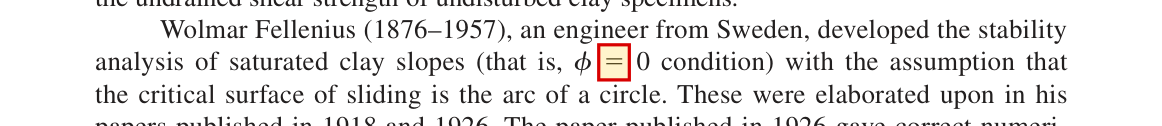

u0002_glyph_18 | PDF page 72 | MathematicalPi-One | U+0002 | glyph 18 | expected visual role: addition sign
  Selected character bbox: (293.22, 614.72, 301.55, 624.72)
  Matching candidates on page: 6


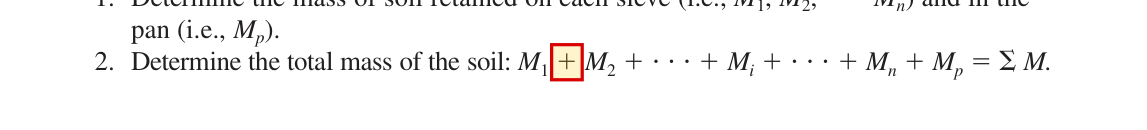

u0005_glyph_15 | PDF page 86 | MathematicalPi-One | U+0005 | glyph 15 | expected visual role: greater-than sign
  Selected character bbox: (399.27, 465.14, 407.6, 475.14)
  Matching candidates on page: 1


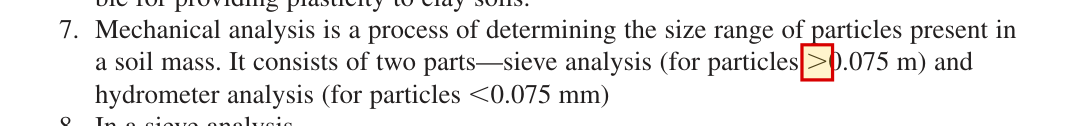

u0005_glyph_20 | PDF page 102 | MathematicalPi-One | U+0005 | glyph 20 | expected visual role: multiplication sign
  Selected character bbox: (279.89, 484.95, 288.22, 494.95)
  Matching candidates on page: 2


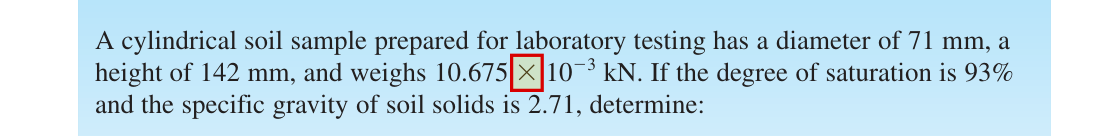

Ambiguous control-code visual proof: COMPLETE


In [20]:
from IPython.display import Image, display


# Select four source-specific examples that demonstrate two ambiguous
# font/code combinations. The glyph IDs were discovered by the
# preceding inventory and are not assumed from the control codes.
CONTROL_GLYPH_VISUAL_PROOFS = (
    {
        "proof_id": "u0002_glyph_22",
        "font": "MathematicalPi-One",
        "code_point": "U+0002",
        "glyph_id": 22,
        "pdf_page_number": 31,
        "target_line_y0": 456.99,
        "expected_visual_role": "equality sign",
    },
    {
        "proof_id": "u0002_glyph_18",
        "font": "MathematicalPi-One",
        "code_point": "U+0002",
        "glyph_id": 18,
        "pdf_page_number": 72,
        "target_line_y0": 614.72,
        "expected_visual_role": "addition sign",
    },
    {
        "proof_id": "u0005_glyph_15",
        "font": "MathematicalPi-One",
        "code_point": "U+0005",
        "glyph_id": 15,
        "pdf_page_number": 86,
        "target_line_y0": 465.14,
        "expected_visual_role": "greater-than sign",
    },
    {
        "proof_id": "u0005_glyph_20",
        "font": "MathematicalPi-One",
        "code_point": "U+0005",
        "glyph_id": 20,
        "pdf_page_number": 102,
        "target_line_y0": 481.32,
        "expected_visual_role": "multiplication sign",
    },
)

# Rendering settings affect only the notebook previews. They do not
# modify the PDF, extracted records or later preprocessing input.
CONTROL_GLYPH_PREVIEW_ZOOM = 2.7
CONTROL_GLYPH_HORIZONTAL_MARGIN = 35.0
CONTROL_GLYPH_VERTICAL_MARGIN = 18.0
CONTROL_GLYPH_HIGHLIGHT_MARGIN = 1.5
CONTROL_GLYPH_LINE_Y_TOLERANCE = 1.0

GLYPH_HIGHLIGHT_BORDER_COLOUR = (
    0.85,
    0.0,
    0.0,
)
GLYPH_HIGHLIGHT_FILL_COLOUR = (
    1.0,
    0.8,
    0.0,
)


def select_visual_proof_occurrence(
    occurrences: list[dict],
    proof_specification: dict,
) -> tuple[dict, int]:
    """
    Select the intended occurrence for one visual proof.

    Several copies of the same glyph may occur on the requested page.
    The known line coordinate is therefore used to choose the intended
    equation while preserving the total candidate count for auditing.

    Returns
    -------
    tuple[dict, int]
        The selected occurrence and the number of records satisfying
        the font, code, glyph and page conditions.
    """

    matching_occurrences = [
        occurrence
        for occurrence in occurrences
        if (
            occurrence["font"]
            == proof_specification["font"]
            and occurrence["code_point"]
            == proof_specification["code_point"]
            and occurrence["glyph_id"]
            == proof_specification["glyph_id"]
            and occurrence["pdf_page_number"]
            == proof_specification[
                "pdf_page_number"
            ]
        )
    ]

    if not matching_occurrences:
        raise ValueError(
            "No glyph-aware occurrence matched visual proof "
            f"{proof_specification['proof_id']}."
        )

    # Choose the line closest to the manually verified source position.
    # The x-coordinate provides stable ordering when a formula contains
    # the same glyph more than once.
    selected_occurrence = min(
        matching_occurrences,
        key=lambda occurrence: (
            abs(
                occurrence["line_bbox"][1]
                - proof_specification[
                    "target_line_y0"
                ]
            ),
            occurrence["character_bbox"][0],
        ),
    )

    line_y_difference = abs(
        selected_occurrence["line_bbox"][1]
        - proof_specification["target_line_y0"]
    )

    if (
        line_y_difference
        > CONTROL_GLYPH_LINE_Y_TOLERANCE
    ):
        raise ValueError(
            "The nearest occurrence is outside the expected "
            f"line tolerance for "
            f"{proof_specification['proof_id']}: "
            f"{line_y_difference:.4f} points."
        )

    return (
        selected_occurrence,
        len(matching_occurrences),
    )


def render_control_glyph_preview(
    pdf_document: pymupdf.Document,
    occurrence: dict,
) -> bytes:
    """
    Render one source line and highlight its matched glyph.

    A temporary in-memory PDF page is used so the verified source PDF
    is never modified. The exact character bounding box is highlighted
    while enough surrounding text is retained to interpret the symbol.
    """

    page_index = occurrence["pdf_page_index"]
    source_page = pdf_document.load_page(
        page_index
    )

    line_x0, line_y0, line_x1, line_y1 = (
        occurrence["line_bbox"]
    )
    (
        character_x0,
        character_y0,
        character_x1,
        character_y1,
    ) = occurrence["character_bbox"]

    preview_document = pymupdf.open()

    try:
        preview_page = preview_document.new_page(
            width=source_page.rect.width,
            height=source_page.rect.height,
        )

        # Copy the original vector page into temporary memory.
        preview_page.show_pdf_page(
            preview_page.rect,
            pdf_document,
            page_index,
        )

        # Expand the character box slightly so the border does not
        # cover the thin strokes of the mathematical symbol.
        highlight_rectangle = pymupdf.Rect(
            max(
                0.0,
                character_x0
                - CONTROL_GLYPH_HIGHLIGHT_MARGIN,
            ),
            max(
                0.0,
                character_y0
                - CONTROL_GLYPH_HIGHLIGHT_MARGIN,
            ),
            min(
                source_page.rect.width,
                character_x1
                + CONTROL_GLYPH_HIGHLIGHT_MARGIN,
            ),
            min(
                source_page.rect.height,
                character_y1
                + CONTROL_GLYPH_HIGHLIGHT_MARGIN,
            ),
        )

        preview_page.draw_rect(
            highlight_rectangle,
            color=(
                GLYPH_HIGHLIGHT_BORDER_COLOUR
            ),
            fill=GLYPH_HIGHLIGHT_FILL_COLOUR,
            width=1.2,
            fill_opacity=0.20,
            overlay=True,
        )

        # Display the complete extracted line with a small margin rather
        # than cropping only the isolated symbol. Formula context is
        # required for reliable human interpretation.
        preview_clip = pymupdf.Rect(
            max(
                0.0,
                line_x0
                - CONTROL_GLYPH_HORIZONTAL_MARGIN,
            ),
            max(
                0.0,
                line_y0
                - CONTROL_GLYPH_VERTICAL_MARGIN,
            ),
            min(
                source_page.rect.width,
                line_x1
                + CONTROL_GLYPH_HORIZONTAL_MARGIN,
            ),
            min(
                source_page.rect.height,
                line_y1
                + CONTROL_GLYPH_VERTICAL_MARGIN,
            ),
        )

        preview_pixmap = preview_page.get_pixmap(
            matrix=pymupdf.Matrix(
                CONTROL_GLYPH_PREVIEW_ZOOM,
                CONTROL_GLYPH_PREVIEW_ZOOM,
            ),
            clip=preview_clip,
            alpha=False,
        )

        return preview_pixmap.tobytes("png")

    finally:
        preview_document.close()


visual_proof_records = []

for proof_specification in (
    CONTROL_GLYPH_VISUAL_PROOFS
):
    (
        selected_occurrence,
        page_candidate_count,
    ) = select_visual_proof_occurrence(
        occurrences=(
            glyph_aware_control_occurrences
        ),
        proof_specification=(
            proof_specification
        ),
    )

    visual_proof_record = {
        **proof_specification,
        "page_candidate_count": (
            page_candidate_count
        ),
        "selected_character_bbox": (
            selected_occurrence[
                "character_bbox"
            ]
        ),
        "selected_line_text": (
            selected_occurrence["line_text"]
        ),
    }
    visual_proof_records.append(
        visual_proof_record
    )

    print(
        f"{proof_specification['proof_id']} | "
        f"PDF page "
        f"{proof_specification['pdf_page_number']} | "
        f"{proof_specification['font']} | "
        f"{proof_specification['code_point']} | "
        f"glyph {proof_specification['glyph_id']} | "
        f"expected visual role: "
        f"{proof_specification['expected_visual_role']}"
    )
    print(
        "  Selected character bbox:",
        tuple(
            round(coordinate, 2)
            for coordinate
            in selected_occurrence[
                "character_bbox"
            ]
        ),
    )
    print(
        "  Matching candidates on page:",
        page_candidate_count,
    )

    preview_png = render_control_glyph_preview(
        pdf_document=document,
        occurrence=selected_occurrence,
    )

    display(
        Image(
            data=preview_png,
            format="png",
        )
    )

# All requested proof examples must be recovered and rendered.
assert (
    len(visual_proof_records)
    == len(CONTROL_GLYPH_VISUAL_PROOFS)
)

print(
    "Ambiguous control-code visual proof: COMPLETE"
)

## Control-character investigation conclusion

The retained textbook extraction contains 9,825 unexpected control-character occurrences across 31 font/code groups. Glyph-aware matching successfully connected every occurrence to its rendered glyph ID using the embedded font name and character origin.

The investigation found that 20 of the 31 font/code groups contain multiple rendered glyph IDs. Visual inspection confirmed that this is not only a technical difference in the PDF encoding. The same extracted font/code combination represents visibly different mathematical symbols:

- `MathematicalPi-One U+0002`, glyph 22 represents an equality sign.
- `MathematicalPi-One U+0002`, glyph 18 represents an addition sign.
- `MathematicalPi-One U+0005`, glyph 15 represents a greater-than sign.
- `MathematicalPi-One U+0005`, glyph 20 represents a multiplication sign.

A global replacement based on the extracted control code, or on the font and control code together, would therefore introduce incorrect mathematical symbols into the corpus.

No replacement mapping is applied in the replication baseline. The extracted controls are retained as a documented limitation of the source PDF's embedded mathematical-font encoding. This keeps the baseline aligned with the preprocessing described in the reference study, which does not report formula-aware glyph reconstruction.

The glyph-aware inventory and visual examples provide evidence for this decision and establish a possible formula-reconstruction enhancement for a later experimental condition. Such an enhancement must remain separate from the replication baseline so that its effect can be evaluated independently.